In [44]:
#1. IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import statsmodels.api as sm

from sklearn.metrics import classification_report, r2_score, accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

#2. LOAD DATA
df = pd.read_csv("mhealth_raw_data.csv")

print(" Dataset Loaded Successfully!\n")
df

 Dataset Loaded Successfully!



,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
0,2.1849,-9.6967,0.63077,0.103900,-0.84053,-0.68762,-8.6499,-4.5781,0.187760,-0.449020,-1.01030,0.034483,0,subject1
1,2.3876,-9.5080,0.68389,0.085343,-0.83865,-0.68369,-8.6275,-4.3198,0.023595,-0.449020,-1.01030,0.034483,0,subject1
2,2.4086,-9.5674,0.68113,0.085343,-0.83865,-0.68369,-8.5055,-4.2772,0.275720,-0.449020,-1.01030,0.034483,0,subject1
3,2.1814,-9.4301,0.55031,0.085343,-0.83865,-0.68369,-8.6279,-4.3163,0.367520,-0.456860,-1.00820,0.025862,0,subject1
4,2.4173,-9.3889,0.71098,0.085343,-0.83865,-0.68369,-8.7008,-4.1459,0.407290,-0.456860,-1.00820,0.025862,0,subject1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1215740,1.7849,-9.8287,0.29725,-0.341370,-0.90056,-0.61493,-3.7198,-8.9071,0.294230,0.041176,-0.99384,-0.480600,0,subject10
1215741,1.8687,-9.8766,0.46236,-0.341370,-0.90056,-0.61493,-3.7160,-8.7455,0.448140,0.041176,-0.99384,-0.480600,0,subject10
1215742,1.6928,-9.9290,0.16631,-0.341370,-0.90056,-0.61493,-3.8824,-9.1155,0.450480,0.041176,-0.99384,-0.480600,0,subject10
1215743,1.5279,-9.6306,0.30458,-0.341370,-0.90056,-0.61493,-3.5564,-9.1441,0.594880,0.041176,-0.99384,-0.480600,0,subject10


In [2]:
print(df.head())

      alx     aly      alz       glx      gly      glz     arx     ary  \
0  2.1849 -9.6967  0.63077  0.103900 -0.84053 -0.68762 -8.6499 -4.5781   
1  2.3876 -9.5080  0.68389  0.085343 -0.83865 -0.68369 -8.6275 -4.3198   
2  2.4086 -9.5674  0.68113  0.085343 -0.83865 -0.68369 -8.5055 -4.2772   
3  2.1814 -9.4301  0.55031  0.085343 -0.83865 -0.68369 -8.6279 -4.3163   
4  2.4173 -9.3889  0.71098  0.085343 -0.83865 -0.68369 -8.7008 -4.1459   

        arz      grx     gry       grz  Activity   subject  
0  0.187760 -0.44902 -1.0103  0.034483         0  subject1  
1  0.023595 -0.44902 -1.0103  0.034483         0  subject1  
2  0.275720 -0.44902 -1.0103  0.034483         0  subject1  
3  0.367520 -0.45686 -1.0082  0.025862         0  subject1  
4  0.407290 -0.45686 -1.0082  0.025862         0  subject1  


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215745 entries, 0 to 1215744
Data columns (total 14 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   alx       1215745 non-null  float64
 1   aly       1215745 non-null  float64
 2   alz       1215745 non-null  float64
 3   glx       1215745 non-null  float64
 4   gly       1215745 non-null  float64
 5   glz       1215745 non-null  float64
 6   arx       1215745 non-null  float64
 7   ary       1215745 non-null  float64
 8   arz       1215745 non-null  float64
 9   grx       1215745 non-null  float64
 10  gry       1215745 non-null  float64
 11  grz       1215745 non-null  float64
 12  Activity  1215745 non-null  int64  
 13  subject   1215745 non-null  object 
dtypes: float64(12), int64(1), object(1)
memory usage: 129.9+ MB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alx,1215745.0,1.494200,3.826485,-22.1460,0.14131,1.308900,2.575800,20.0540
aly,1215745.0,-9.692878,4.171303,-19.6190,-10.20100,-9.670300,-9.042200,21.1610
alz,1215745.0,-0.954806,5.461803,-19.3730,-2.64940,-0.016456,1.301300,25.0150
glx,1215745.0,-0.001599,0.491217,-2.1466,-0.43599,-0.014842,0.448980,60.4840
gly,1215745.0,-0.616632,0.354641,-7.7899,-0.81801,-0.707320,-0.540340,2.0113
glz,1215745.0,-0.158781,0.546798,-2.6267,-0.59332,-0.190570,0.322200,2.7701
arx,1215745.0,-3.713413,4.763586,-22.3610,-6.07600,-2.977600,-1.193700,19.8640
ary,1215745.0,-5.805526,5.757639,-18.9720,-9.40420,-7.461500,-2.533900,22.1910
arz,1215745.0,2.393880,3.876503,-18.2390,0.12965,1.928100,4.914700,25.7410
grx,1215745.0,-0.276106,0.527689,-8.3392,-0.70588,-0.354900,0.096078,3.3196


In [5]:
df.isnull().sum()

alx         0
aly         0
alz         0
glx         0
gly         0
glz         0
arx         0
ary         0
arz         0
grx         0
gry         0
grz         0
Activity    0
subject     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Activity'>

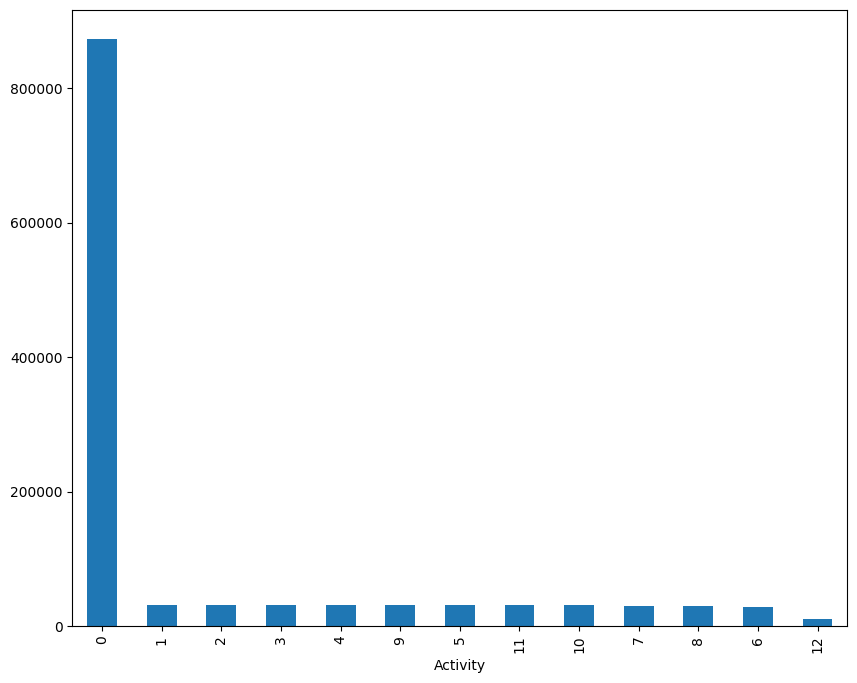

In [7]:
plt.figure(figsize=(10,8))
df['Activity'].value_counts().plot.bar()

In [8]:
data_activity_0 = df[df["Activity"] == 0]
data_activity_else = df[df["Activity"] != 0]

In [9]:
data_activity_0 = data_activity_0.sample(n=40000)
df = pd.concat([data_activity_0, data_activity_else])

<Axes: xlabel='Activity'>

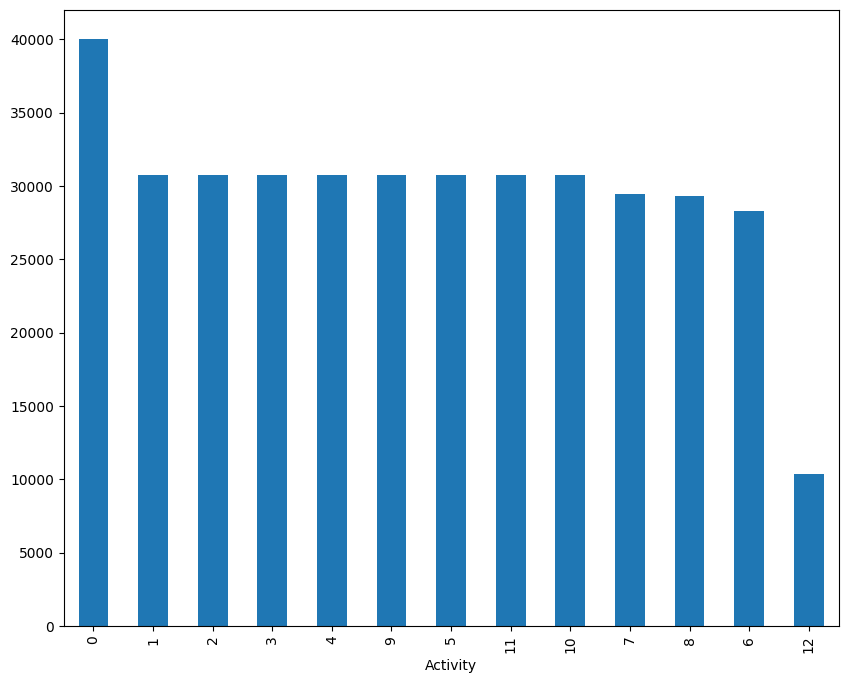

In [10]:
plt.figure(figsize=(10,8))
df['Activity'].value_counts().plot.bar()

In [11]:
len(df)

383195

In [12]:
activity_label = {
    0: "None",
    1: "Standing still (1 min)",
    2: "Sitting and relaxing (1 min)",
    3: "Lying down (1 min)",
    4: "Walking (1 min)",
    5: "Climbing stairs (1 min)",
    6: "Waist bends forward (20x)",
    7: "Frontal elevation of arms (20x)",
    8: "Knees bending (crouching) (20x)",
    9: "Cycling (1 min)",
    10: "Jogging (1 min)",
    11: "Running (1 min)",
    12: "Jump front & back (20x)"
}

====================Standing still (1 min) - a====================


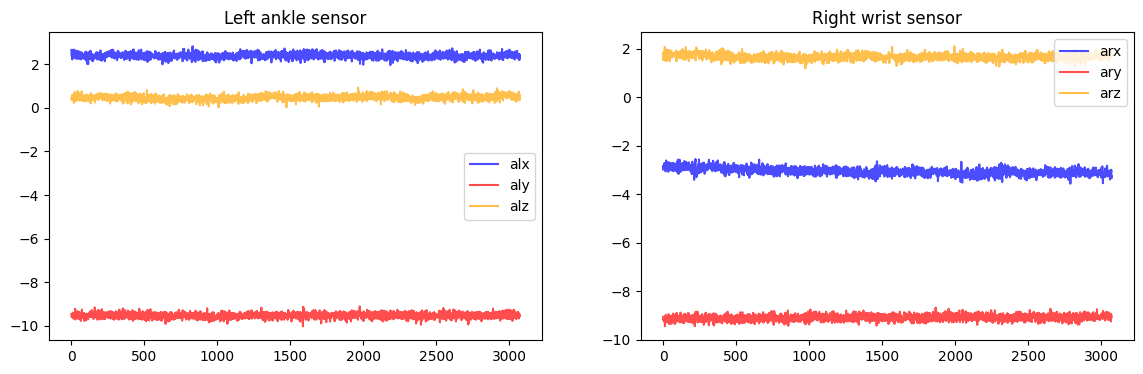

====================Standing still (1 min) - g====================


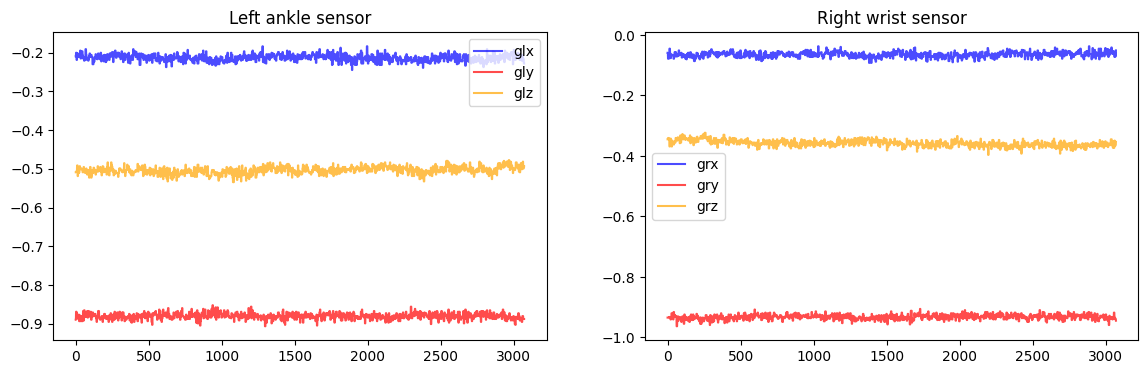

====================Sitting and relaxing (1 min) - a====================


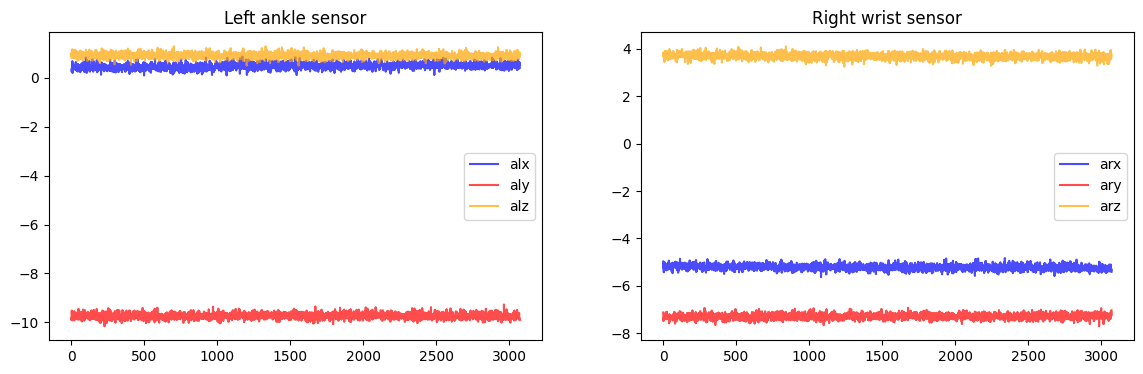

====================Sitting and relaxing (1 min) - g====================


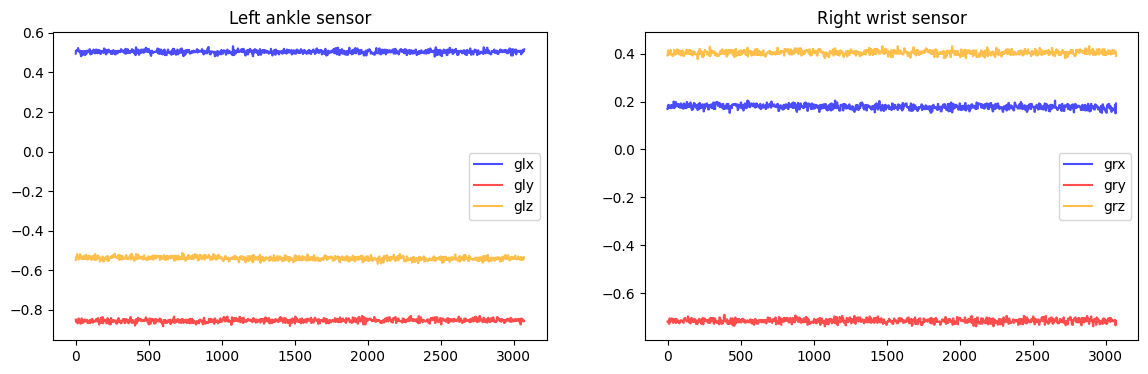

====================Lying down (1 min) - a====================


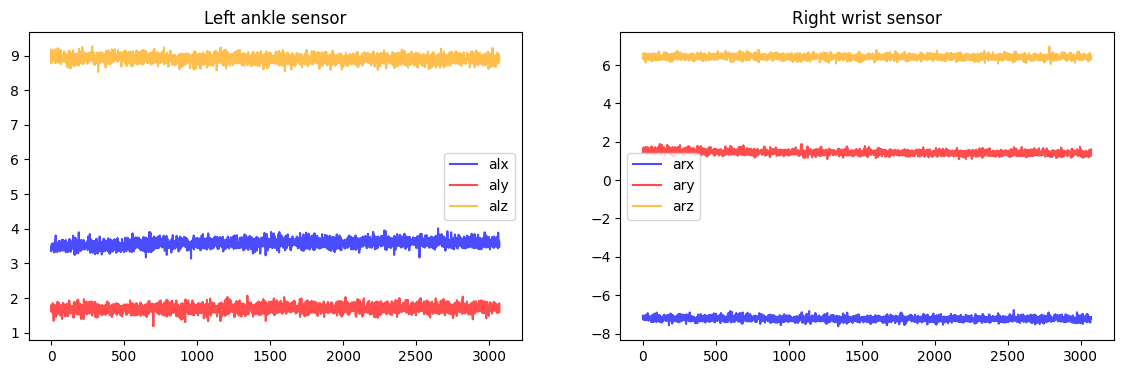

====================Lying down (1 min) - g====================


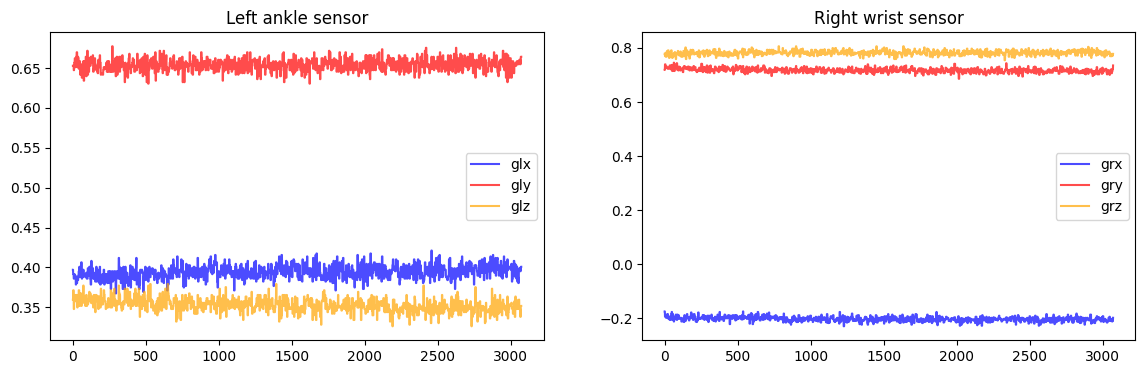

====================Walking (1 min) - a====================


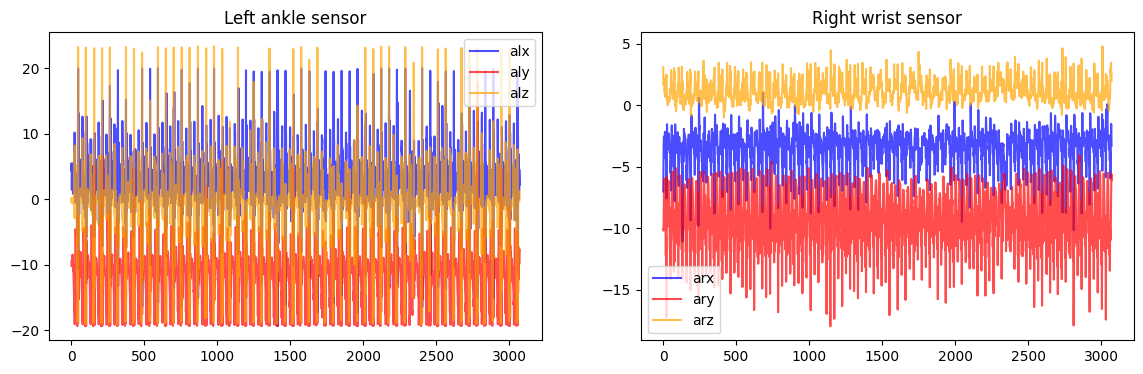

====================Walking (1 min) - g====================


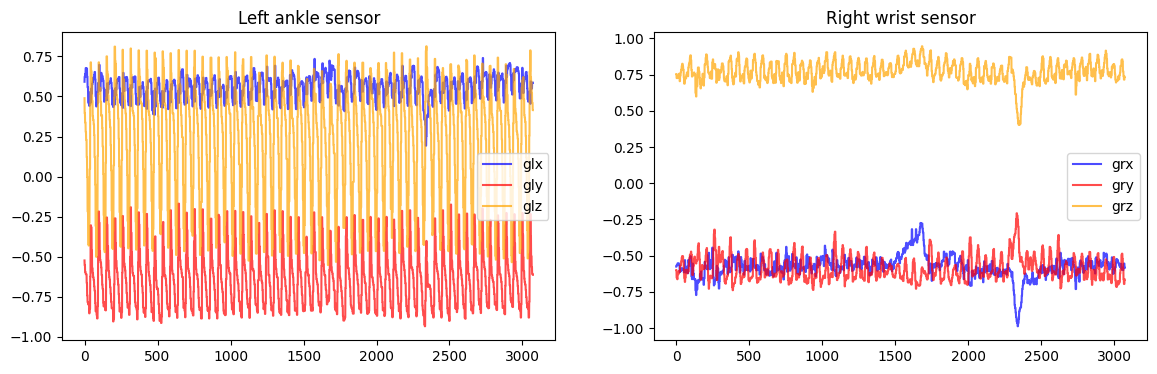

====================Climbing stairs (1 min) - a====================


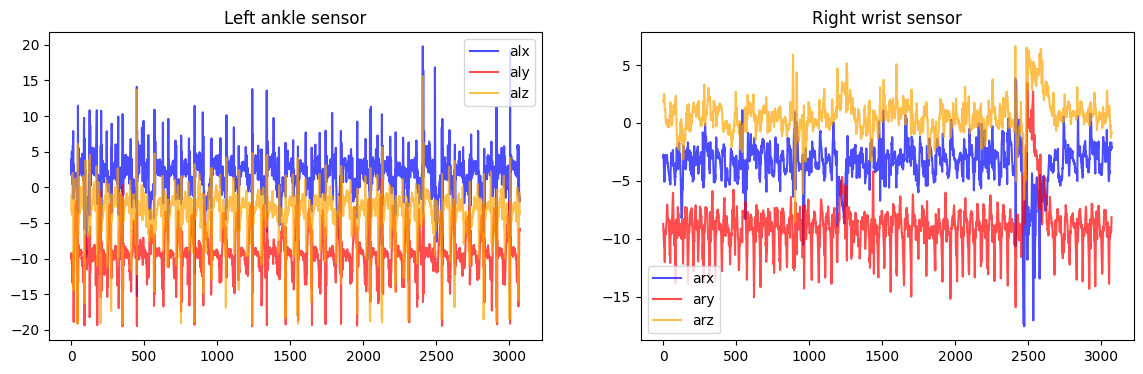

====================Climbing stairs (1 min) - g====================


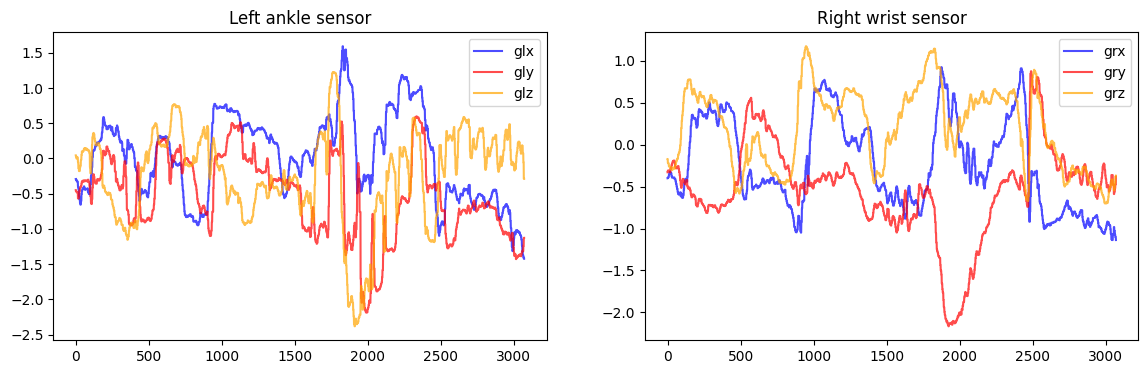

====================Waist bends forward (20x) - a====================


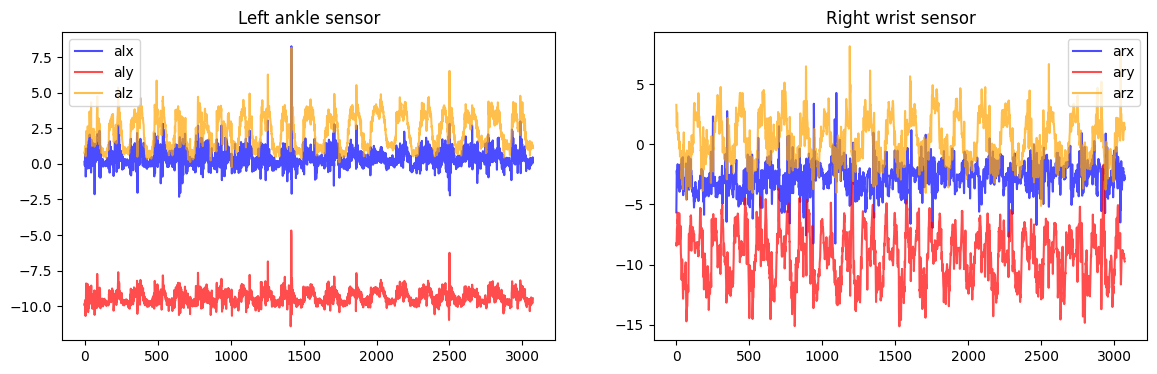

====================Waist bends forward (20x) - g====================


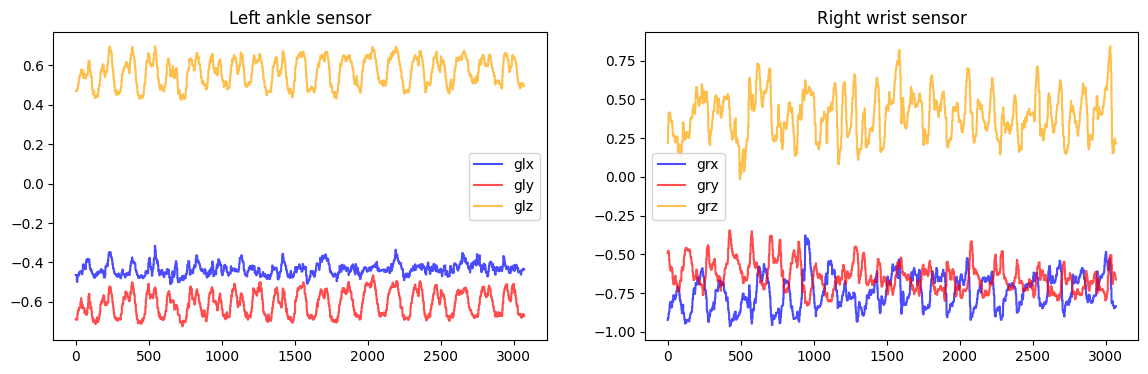

====================Frontal elevation of arms (20x) - a====================


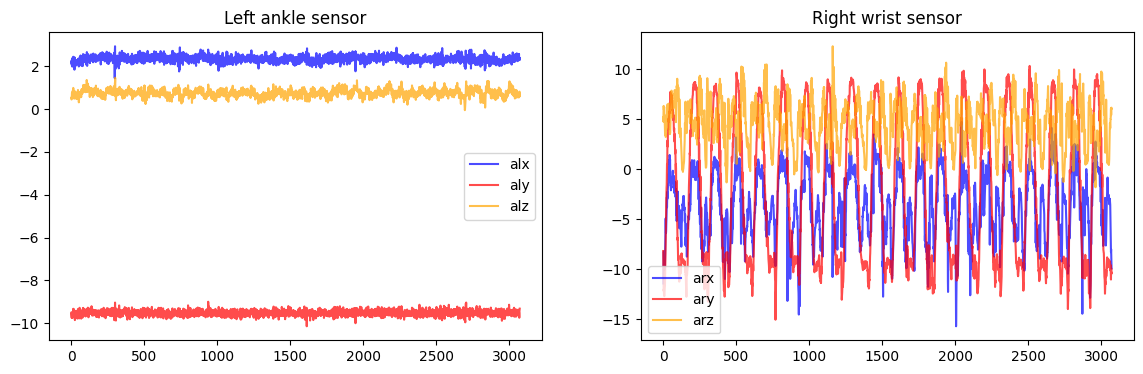

====================Frontal elevation of arms (20x) - g====================


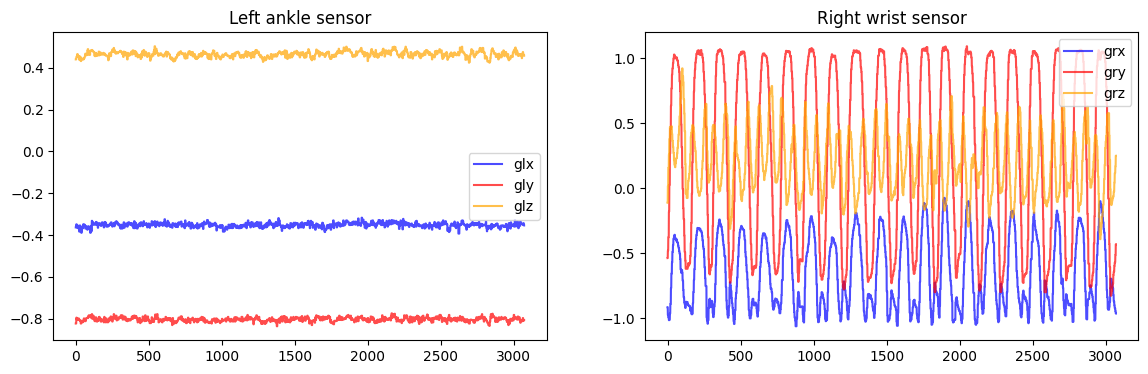

====================Knees bending (crouching) (20x) - a====================


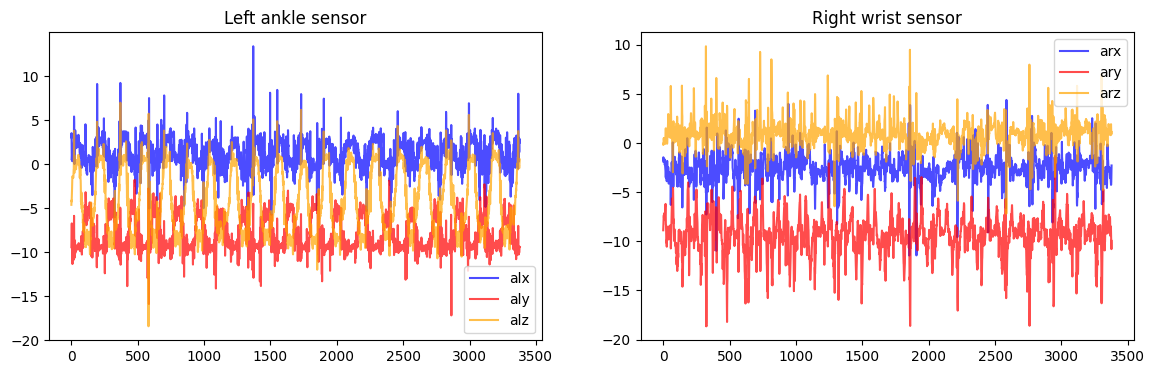

====================Knees bending (crouching) (20x) - g====================


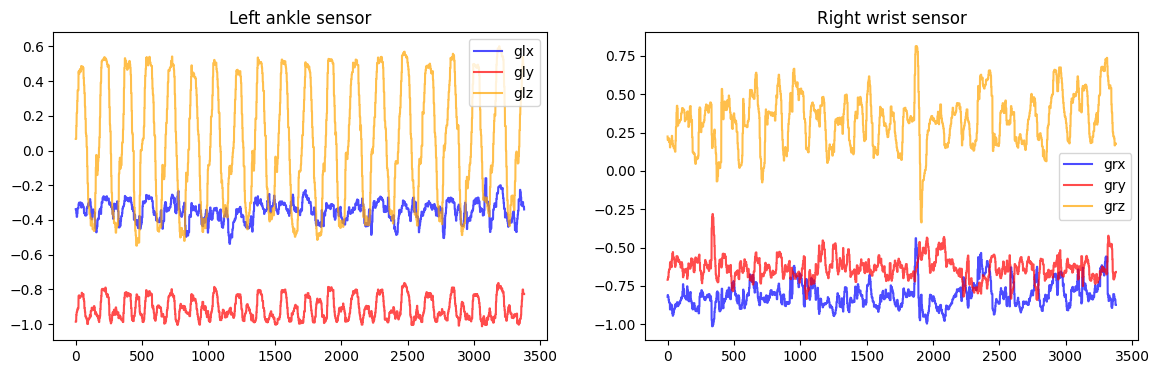

====================Cycling (1 min) - a====================


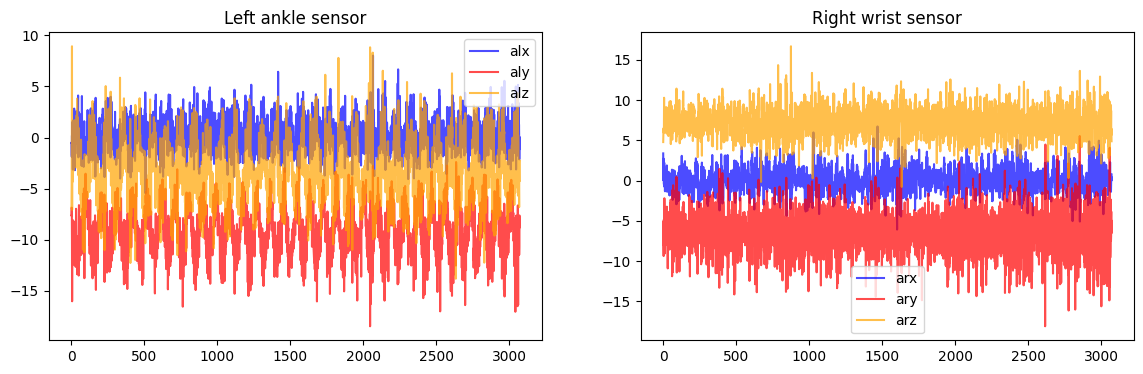

====================Cycling (1 min) - g====================


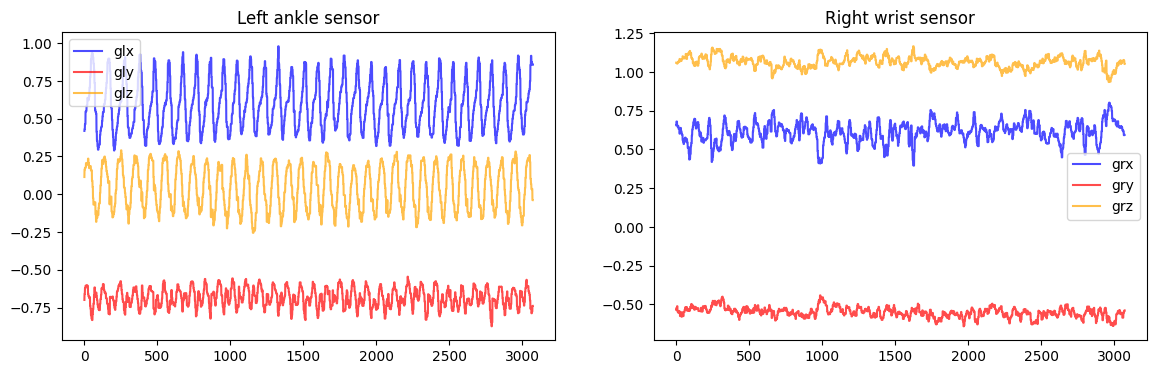

====================Jogging (1 min) - a====================


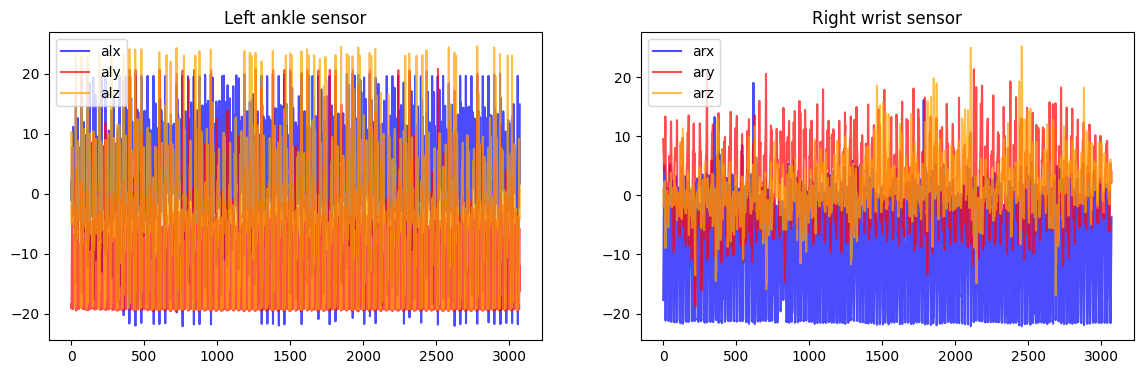

====================Jogging (1 min) - g====================


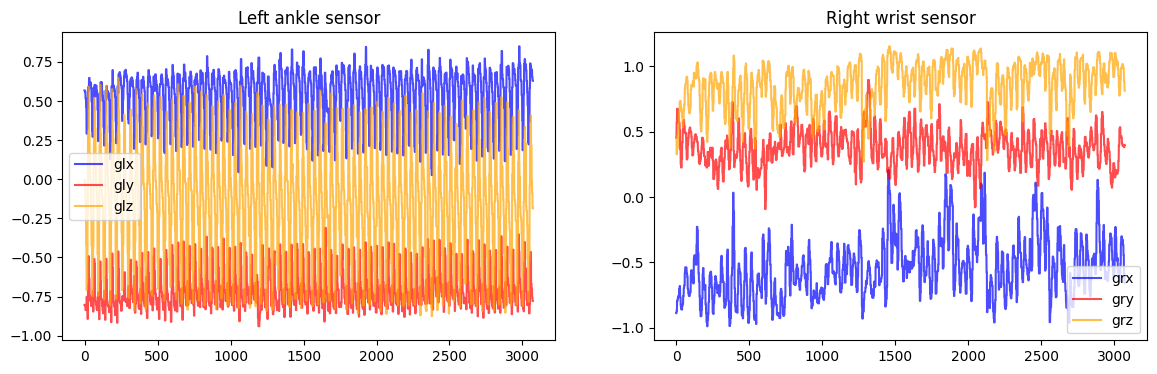

====================Running (1 min) - a====================


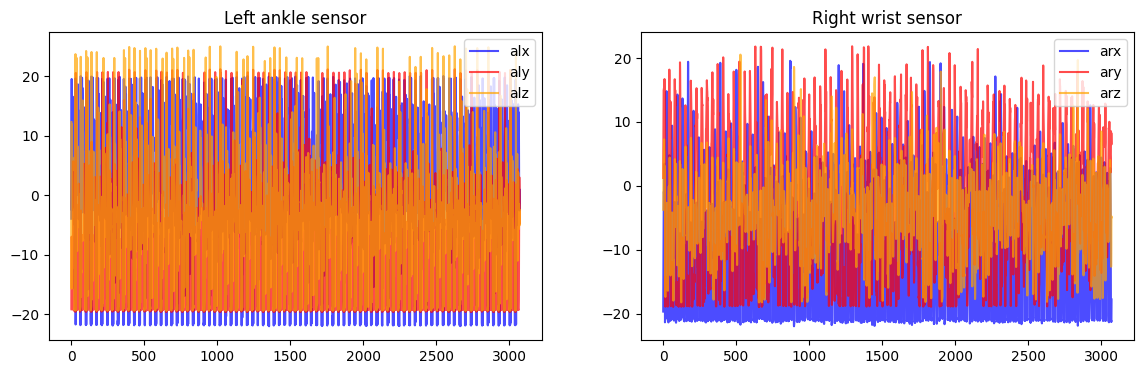

====================Running (1 min) - g====================


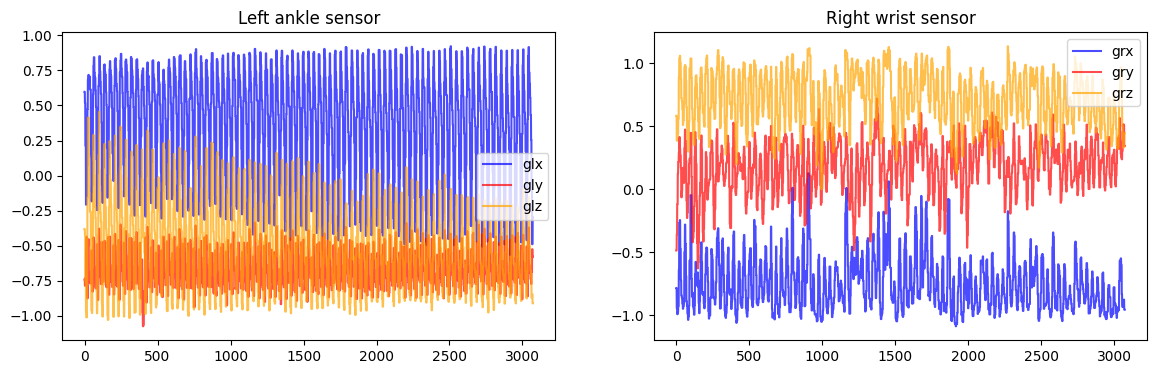

====================Jump front & back (20x) - a====================


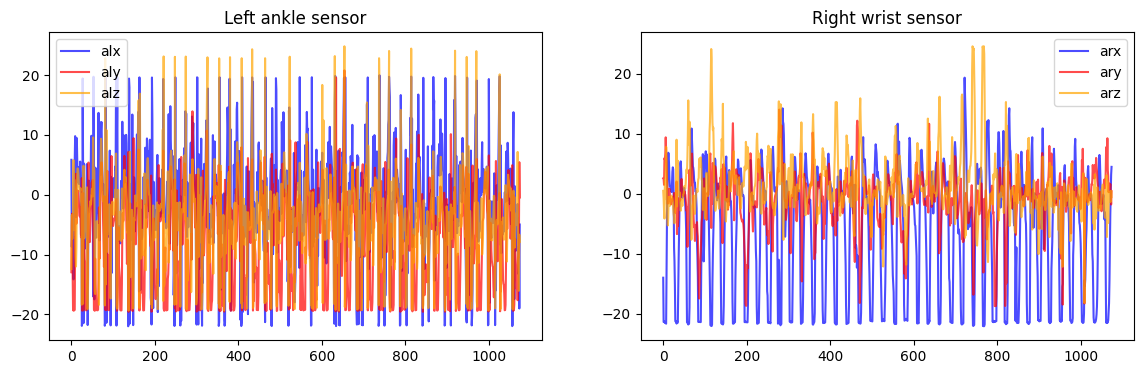

====================Jump front & back (20x) - g====================


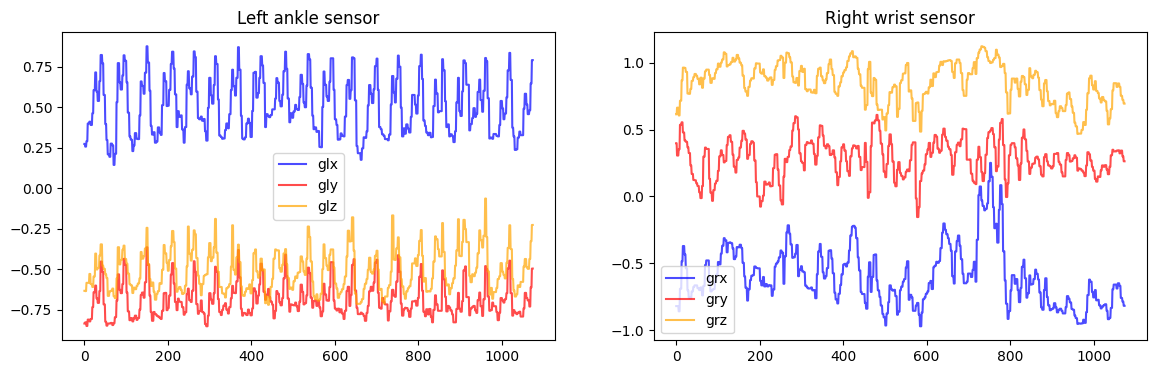

In [13]:
subject1 = df[df['subject'] == 'subject1']
readings = ['a', 'g']

for i in range(1,13):
    for r in readings:
        print(f"===================={activity_label[i]} - {r}====================")
        plt.figure(figsize=(14,4))

        plt.subplot(1,2,1)
        plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "lx"],
                 color='blue', alpha=0.7, label=r + "lx")
        plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "ly"],
                 color='red', alpha=0.7, label=r + "ly")
        plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "lz"],
                 color='orange', alpha=0.7, label=r + "lz")
        plt.title("Left ankle sensor")
        plt.legend()

        plt.subplot(1,2,2)
        plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "rx"],
                 color='blue', alpha=0.7, label=r + "rx")
        plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "ry"],
                 color='red', alpha=0.7, label=r + "ry")
        plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "rz"],
                 color='orange', alpha=0.7, label=r + "rz")
        plt.title("Right wrist sensor")
        plt.legend()
        plt.show()

====================Standing still (1 min) - a====================


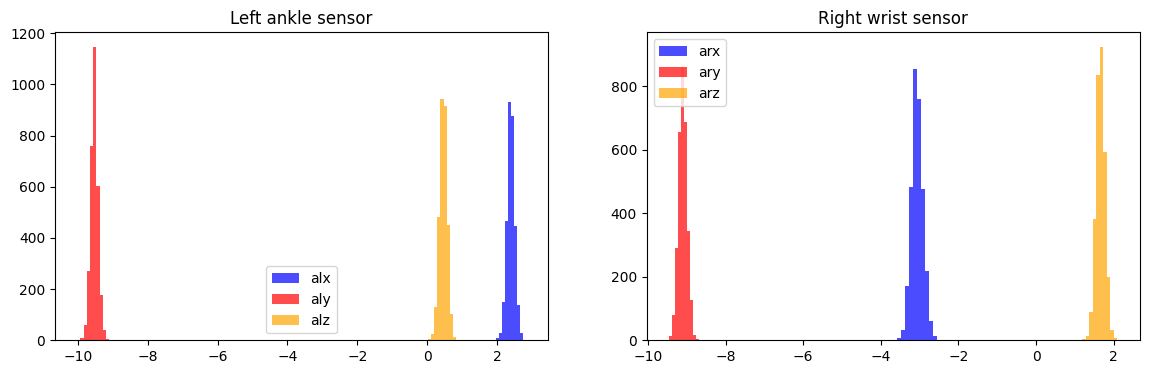

====================Standing still (1 min) - g====================


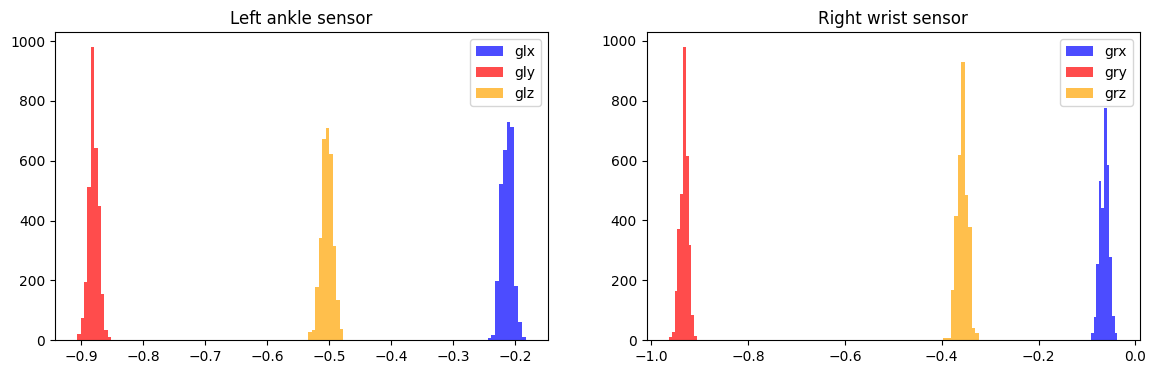

====================Sitting and relaxing (1 min) - a====================


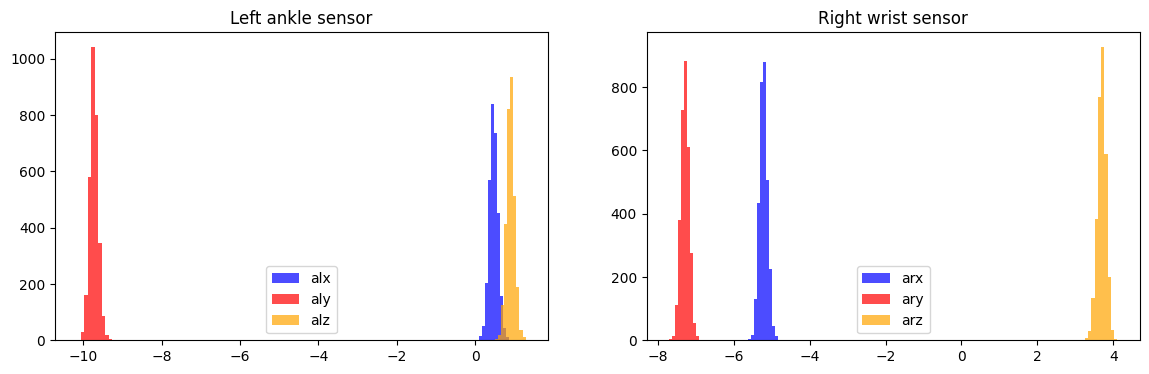

====================Sitting and relaxing (1 min) - g====================


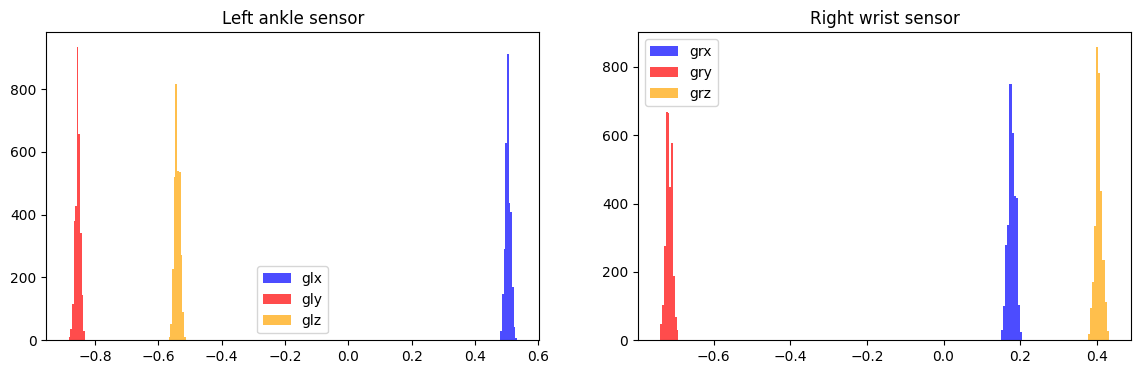

====================Lying down (1 min) - a====================


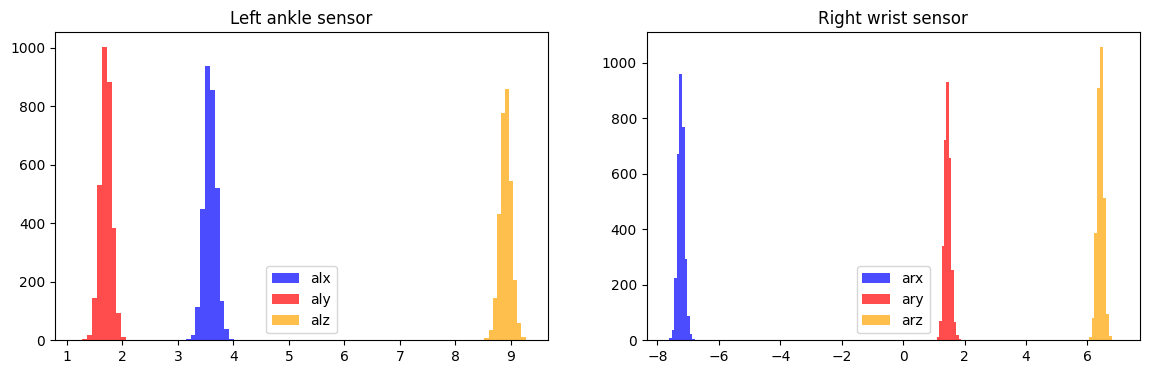

====================Lying down (1 min) - g====================


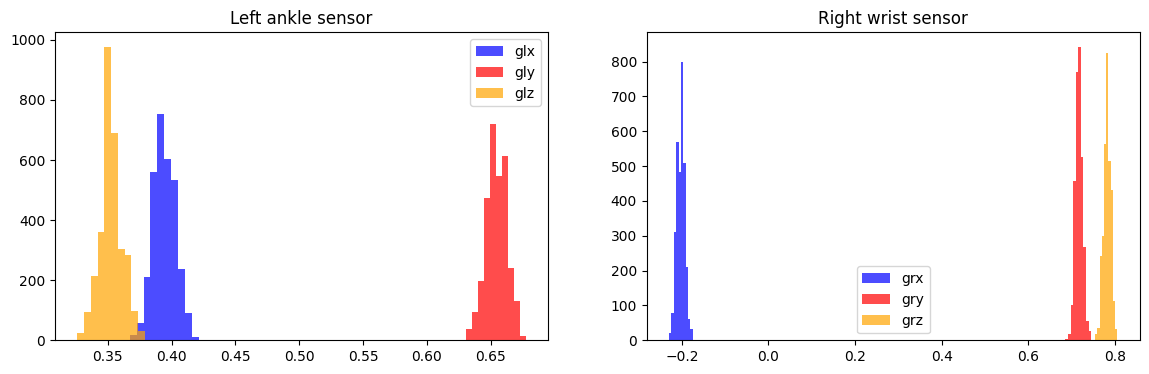

====================Walking (1 min) - a====================


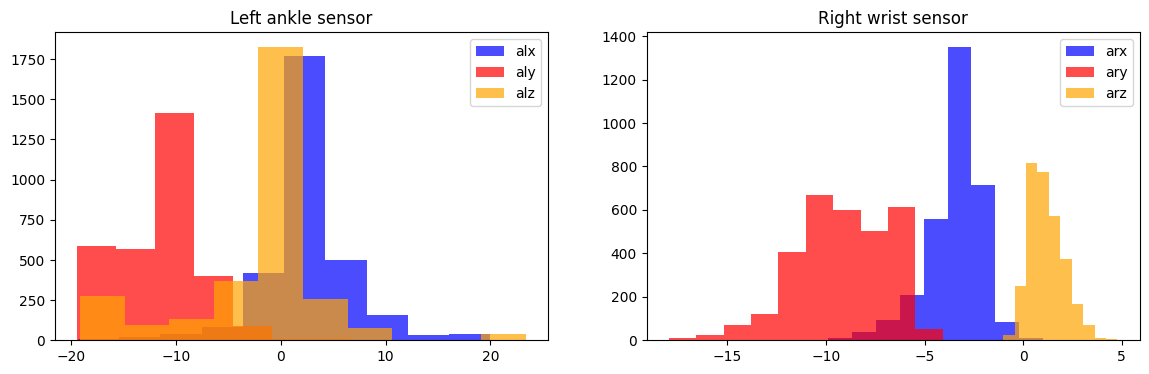

====================Walking (1 min) - g====================


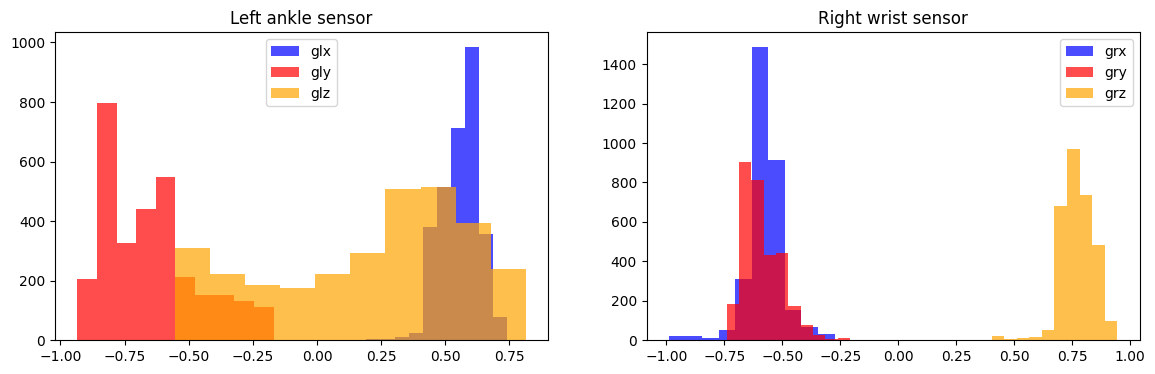

====================Climbing stairs (1 min) - a====================


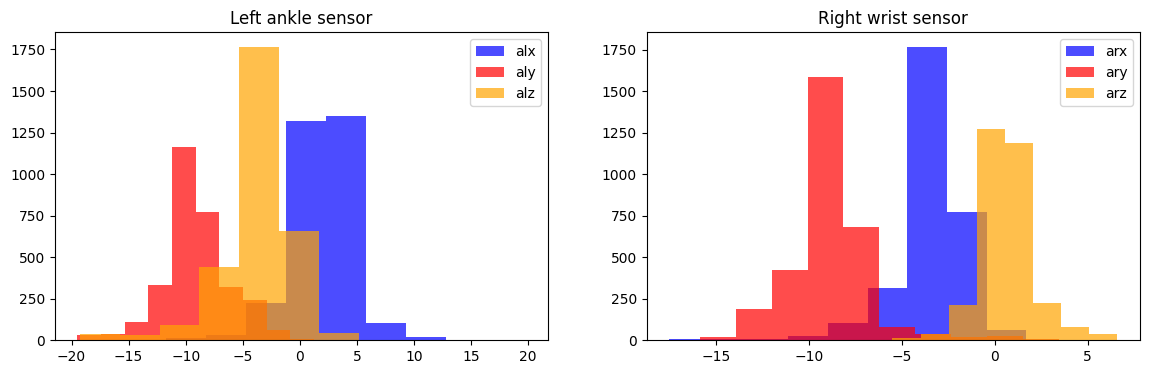

====================Climbing stairs (1 min) - g====================


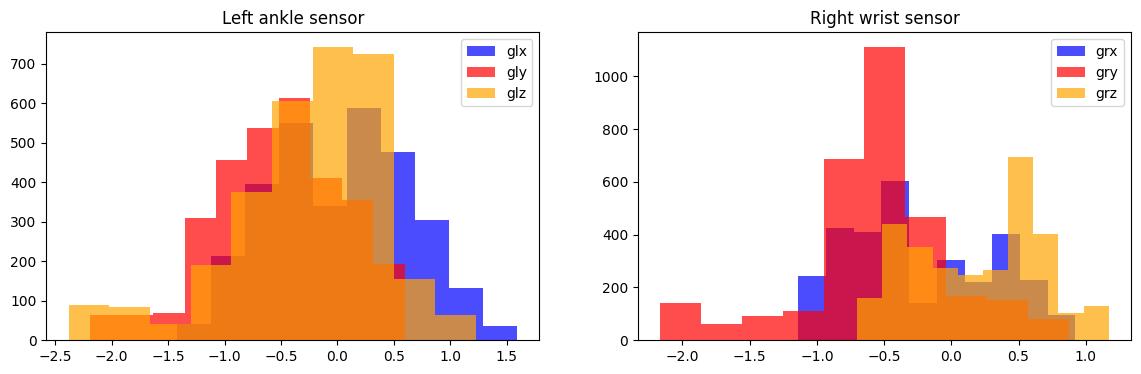

====================Waist bends forward (20x) - a====================


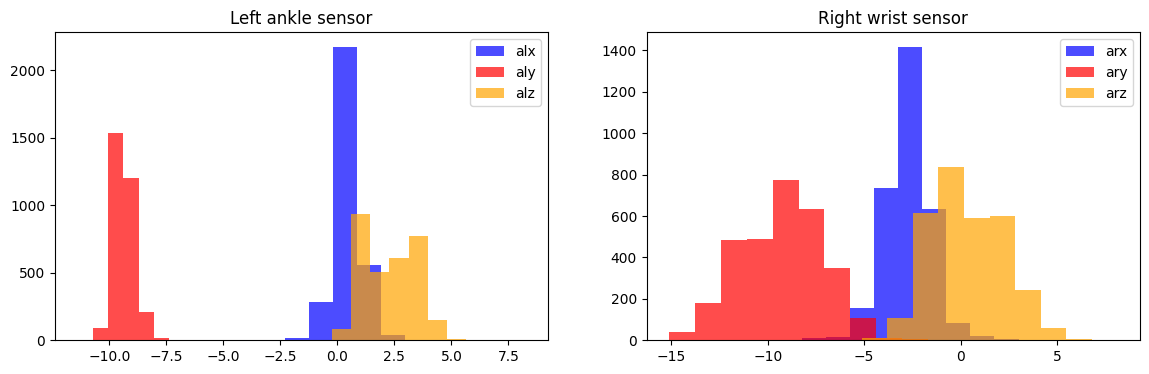

====================Waist bends forward (20x) - g====================


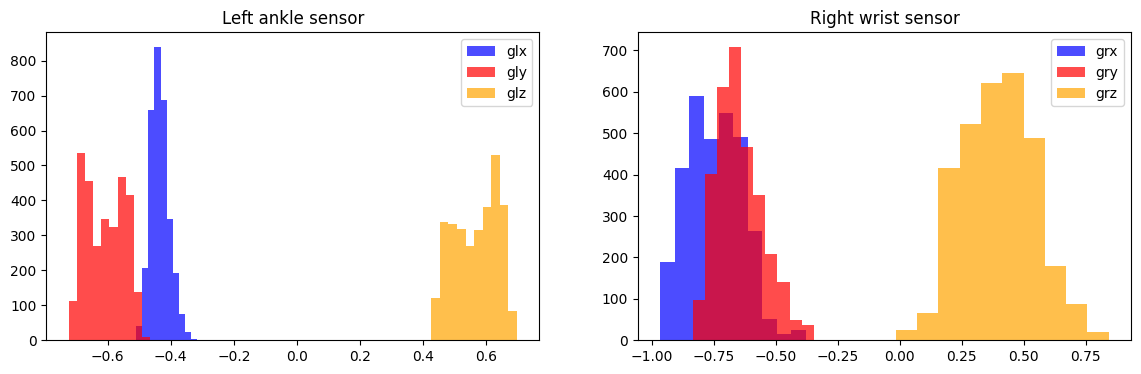

====================Frontal elevation of arms (20x) - a====================


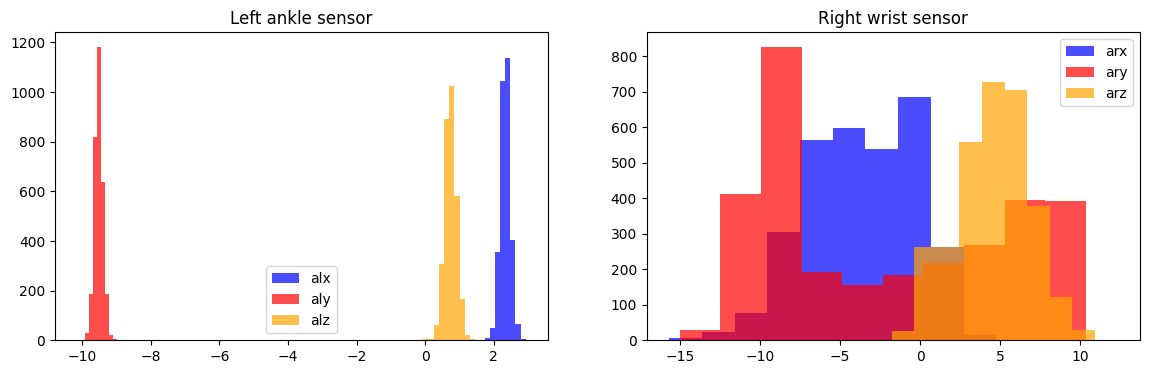

====================Frontal elevation of arms (20x) - g====================


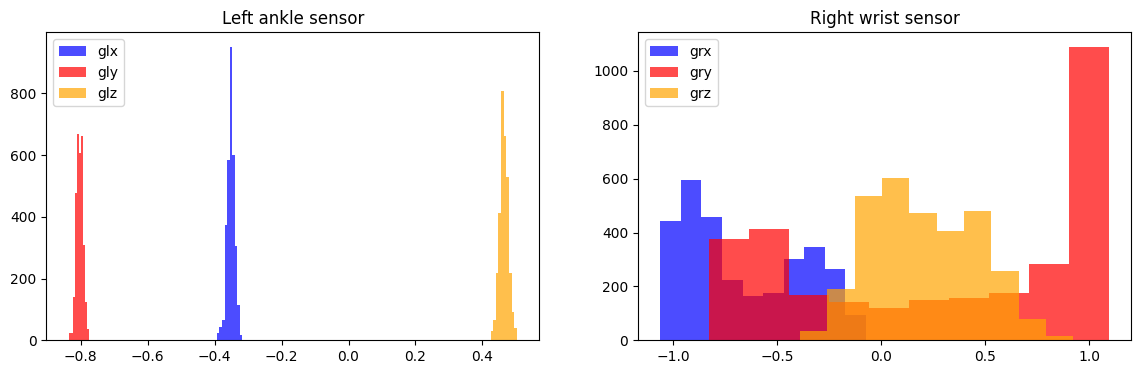

====================Knees bending (crouching) (20x) - a====================


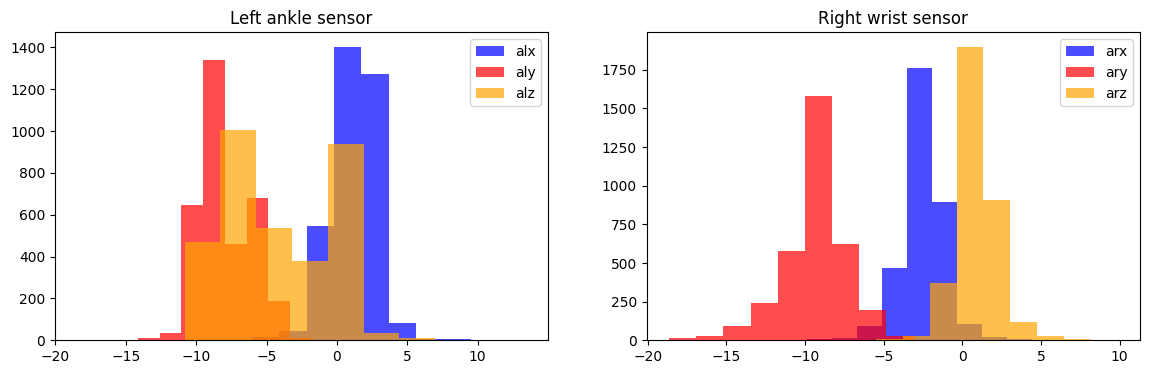

====================Knees bending (crouching) (20x) - g====================


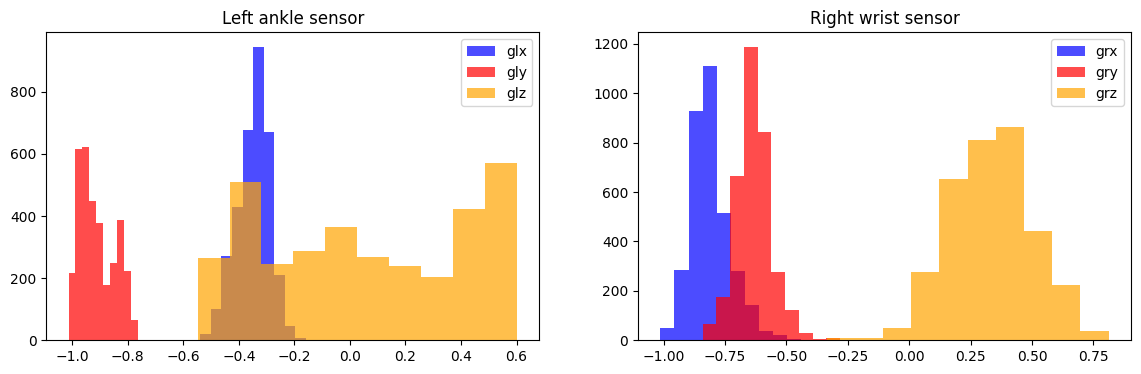

====================Cycling (1 min) - a====================


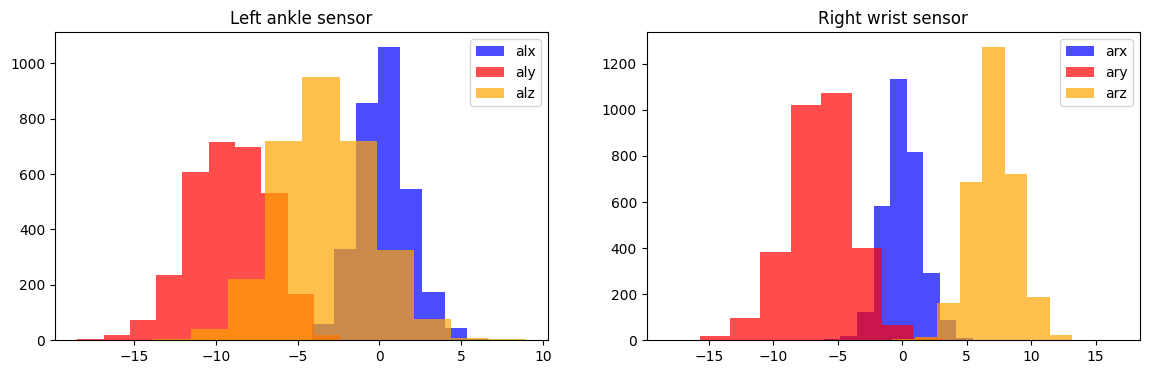

====================Cycling (1 min) - g====================


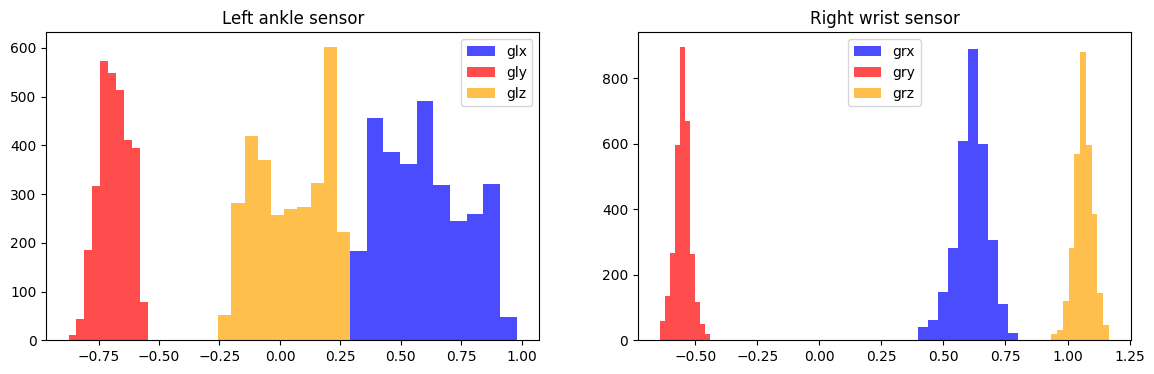

====================Jogging (1 min) - a====================


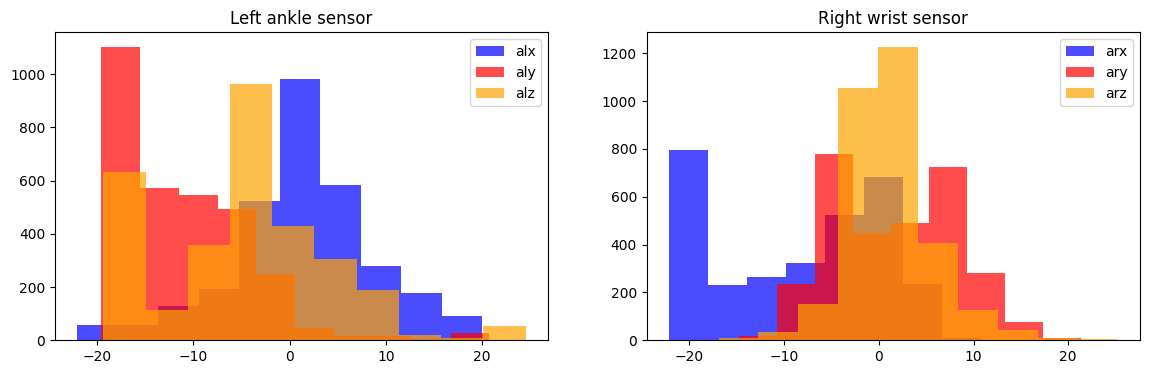

====================Jogging (1 min) - g====================


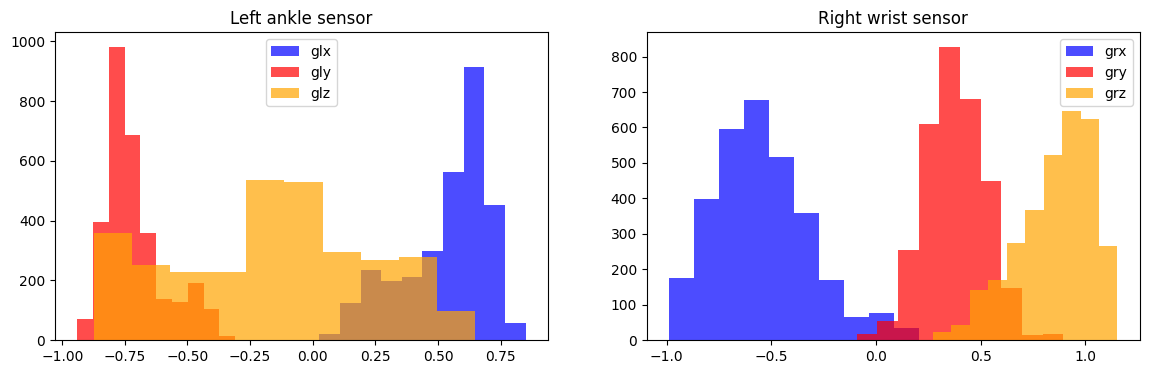

====================Running (1 min) - a====================


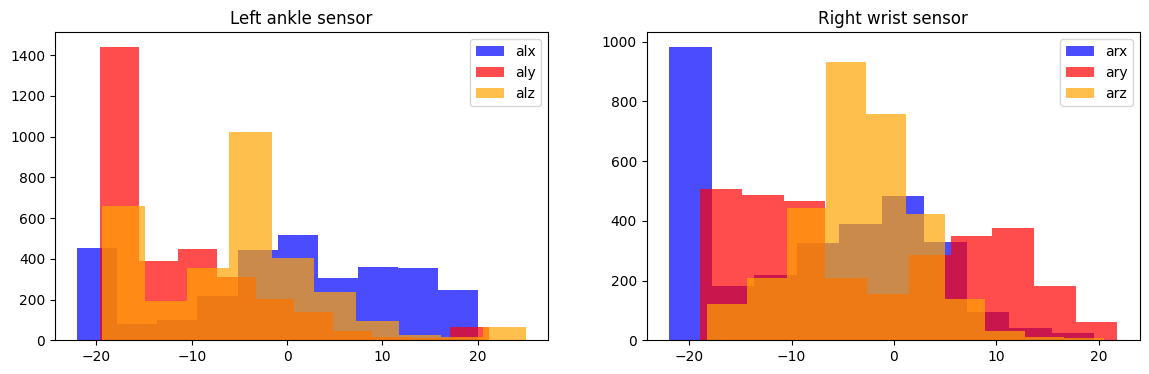

====================Running (1 min) - g====================


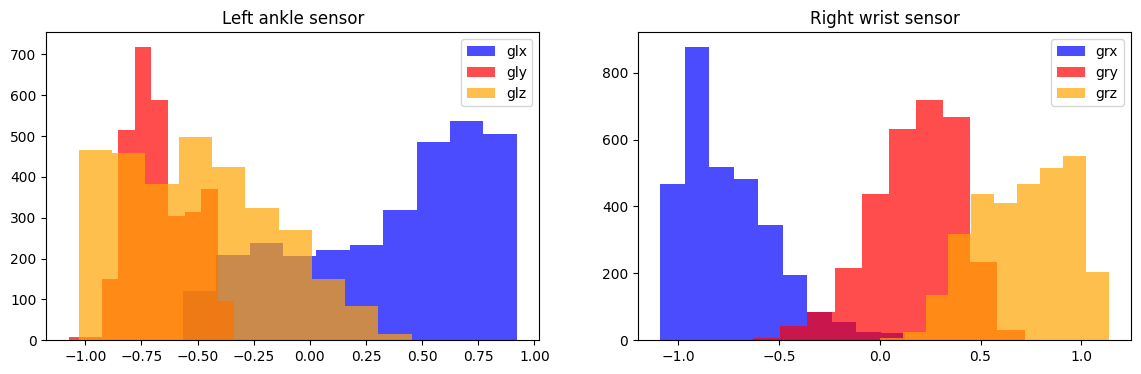

====================Jump front & back (20x) - a====================


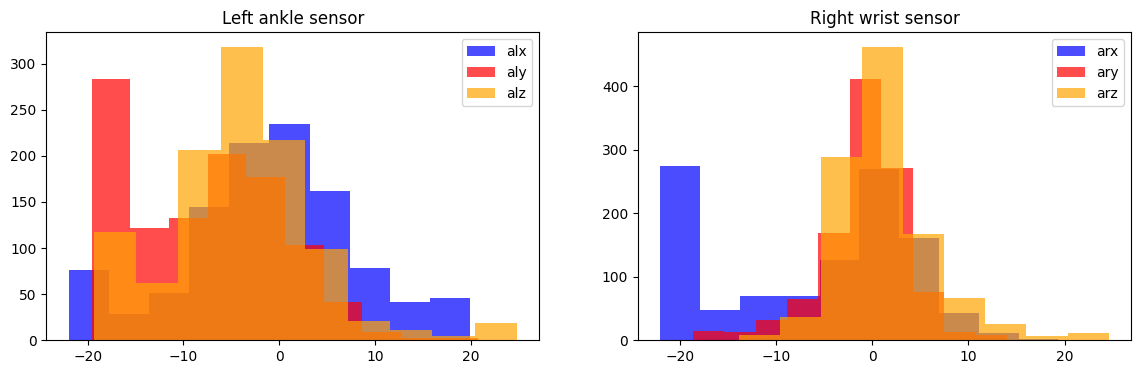

====================Jump front & back (20x) - g====================


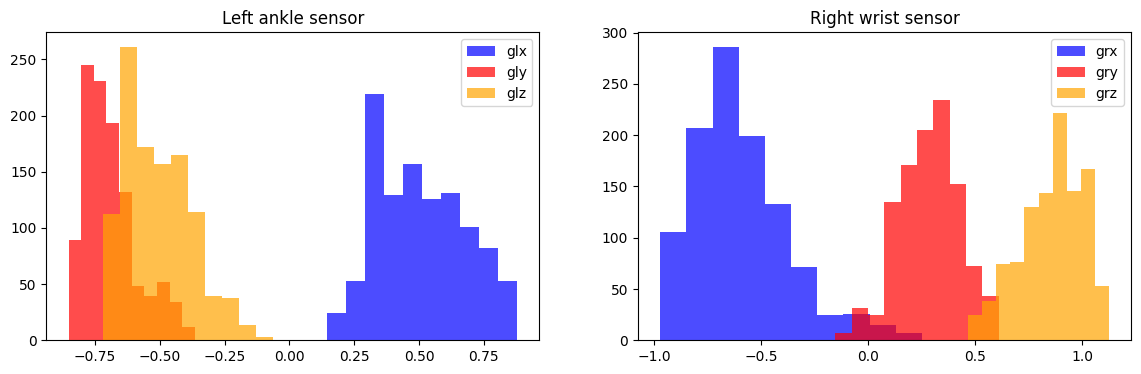

In [14]:
for i in range(1,13):
    for r in readings:
        print(f"===================={activity_label[i]} - {r}====================")
        plt.figure(figsize=(14,4))

        plt.subplot(1,2,1)
        plt.hist(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "lx"],
                 color='blue', alpha=0.7, label=r + "lx")
        plt.hist(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "ly"],
                 color='red', alpha=0.7, label=r + "ly")
        plt.hist(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "lz"],
                 color='orange', alpha=0.7, label=r + "lz")
        plt.title("Left ankle sensor")
        plt.legend()

        plt.subplot(1,2,2)
        plt.hist(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "rx"],
                 color='blue', alpha=0.7, label=r + "rx")
        plt.hist(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "ry"],
                 color='red', alpha=0.7, label=r + "ry")
        plt.hist(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "rz"],
                 color='orange', alpha=0.7, label=r + "rz")
        plt.title("Right wrist sensor")
        plt.legend()
        plt.show()

In [15]:
df['Activity'] = df['Activity'].replace([0,1,2,3,4,5,6,7,8,9,10,11,12],['None',
                                                                        'Standing still (1 min)',
                                                                        'Sitting and relaxing (1 min)',
                                                                        'Lying down (1 min)',
                                                                        'Walking (1 min)',
                                                                        'Climbing stairs (1 min)',
                                                                        'Waist bends forward (20x)',
                                                                        'Frontal elevation of arms (20x)',
                                                                        'Knees bending (crouching) (20x)',
                                                                        'Cycling (1 min)','Jogging (1 min)',
                                                                        'Running (1 min)','Jump front & back (20x)'])


In [16]:
df["Activity"]

683684                        None
595799                        None
46419                         None
705204                        None
626867                        None
                    ...           
1213641    Jump front & back (20x)
1213642    Jump front & back (20x)
1213643    Jump front & back (20x)
1213644    Jump front & back (20x)
1213645    Jump front & back (20x)
Name: Activity, Length: 383195, dtype: object

In [17]:
df.Activity.value_counts()

Activity
None                               40000
Standing still (1 min)             30720
Sitting and relaxing (1 min)       30720
Lying down (1 min)                 30720
Walking (1 min)                    30720
Cycling (1 min)                    30720
Climbing stairs (1 min)            30720
Running (1 min)                    30720
Jogging (1 min)                    30720
Frontal elevation of arms (20x)    29441
Knees bending (crouching) (20x)    29337
Waist bends forward (20x)          28315
Jump front & back (20x)            10342
Name: count, dtype: int64

<Axes: ylabel='count'>

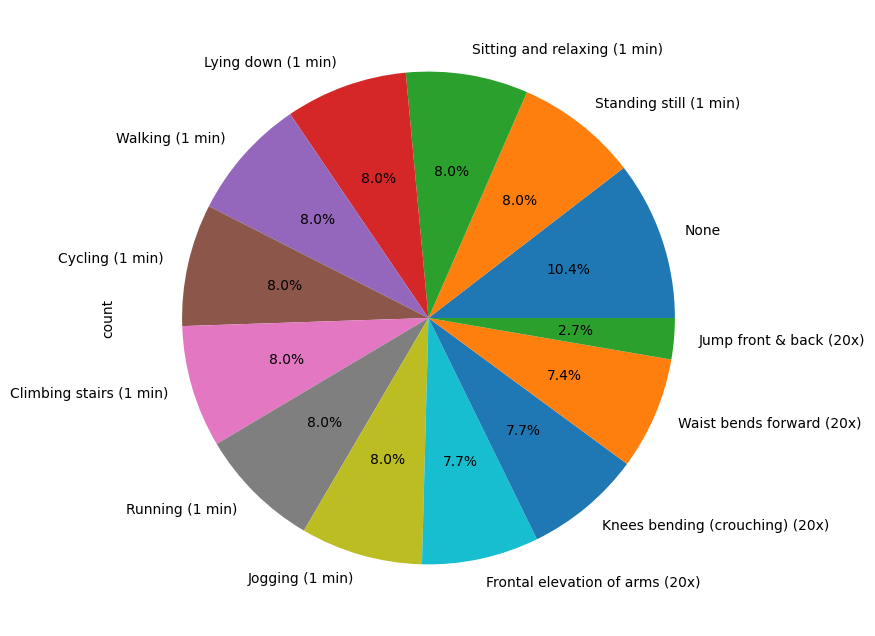

In [18]:
plt.figure(figsize=(12,8))
round((df['Activity'].value_counts()/df.shape[0]*100),2).plot.pie(autopct='%2.1f%%')

In [19]:
df1 = df.copy()

for feature in df1.columns[:-2]:
    lower_range = np.quantile(df[feature], 0.01)
    upper_range = np.quantile(df[feature], 0.99)
    print(feature, "range:", lower_range, "to", upper_range)

    df1 = df1.drop(df1[(df1[feature] > upper_range) | (df1[feature] < lower_range)].index, axis=0)

print("shape", df1.shape)

alx range: -11.504059999999999 to 19.229
aly range: -19.378 to 2.383825999999995
alz range: -18.949 to 14.139
glx range: -0.75325 to 0.80891
gly range: -1.0657 to 0.96435
glz range: -1.1061 to 0.8290799999999999
arx range: -21.487 to 9.049729999999998
ary range: -18.691 to 11.829179999999994
arz range: -10.25706 to 11.767059999999997
grx range: -1.0216 to 0.95294
gry range: -1.1437 to 0.90965
grz range: -0.7069 to 1.125
shape (318773, 14)


In [20]:
df1

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
683684,1.48070,-9.72650,1.61180,-0.183670,-0.86867,-0.54224,-3.2125,-9.049000,2.09960,-0.027451,-1.02260,-0.381470,None,subject6
595799,0.90778,-9.63830,0.52716,-0.070501,-0.80863,-0.71316,-6.1749,-5.171100,5.88730,-0.909800,-0.56263,0.028017,None,subject5
705204,13.46400,-14.98400,-5.36460,0.285710,-0.94747,-0.12181,-6.5616,-15.079000,5.07940,-0.278430,-0.98152,0.463360,None,subject6
576545,1.22060,-11.54100,0.31013,-0.400740,-0.64916,-0.68566,1.5661,-4.603300,6.66570,-0.182350,-1.09650,0.463360,None,subject5
227655,-1.81360,-8.54970,-13.38300,-0.400740,-0.95122,-0.13949,-1.9535,-8.258000,1.20170,-0.072549,-1.10270,-0.185340,None,subject2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213636,-0.19979,-0.93484,2.55540,0.630800,-0.52533,-0.67976,-4.0212,-0.082645,0.73545,-0.458820,-1.00000,0.122840,Jump front & back (20x),subject10
1213637,-0.33315,-1.23710,-2.91940,0.638220,-0.42777,-0.74853,-2.2515,-0.414790,0.52093,-0.417650,-1.03700,0.088362,Jump front & back (20x),subject10
1213640,6.77570,-15.07500,7.39740,0.619670,-0.33771,-0.82711,-2.2797,-2.358900,2.11120,-0.417650,-1.03700,0.088362,Jump front & back (20x),subject10
1213641,-2.48730,-19.23300,3.46140,0.619670,-0.33771,-0.82711,-8.2348,-4.965200,2.48090,-0.437250,-1.01850,0.079741,Jump front & back (20x),subject10


In [21]:
le = LabelEncoder()
df['subject'] = le.fit_transform(df['subject'])

In [22]:
df['Activity'] = le.fit_transform(df['Activity'])

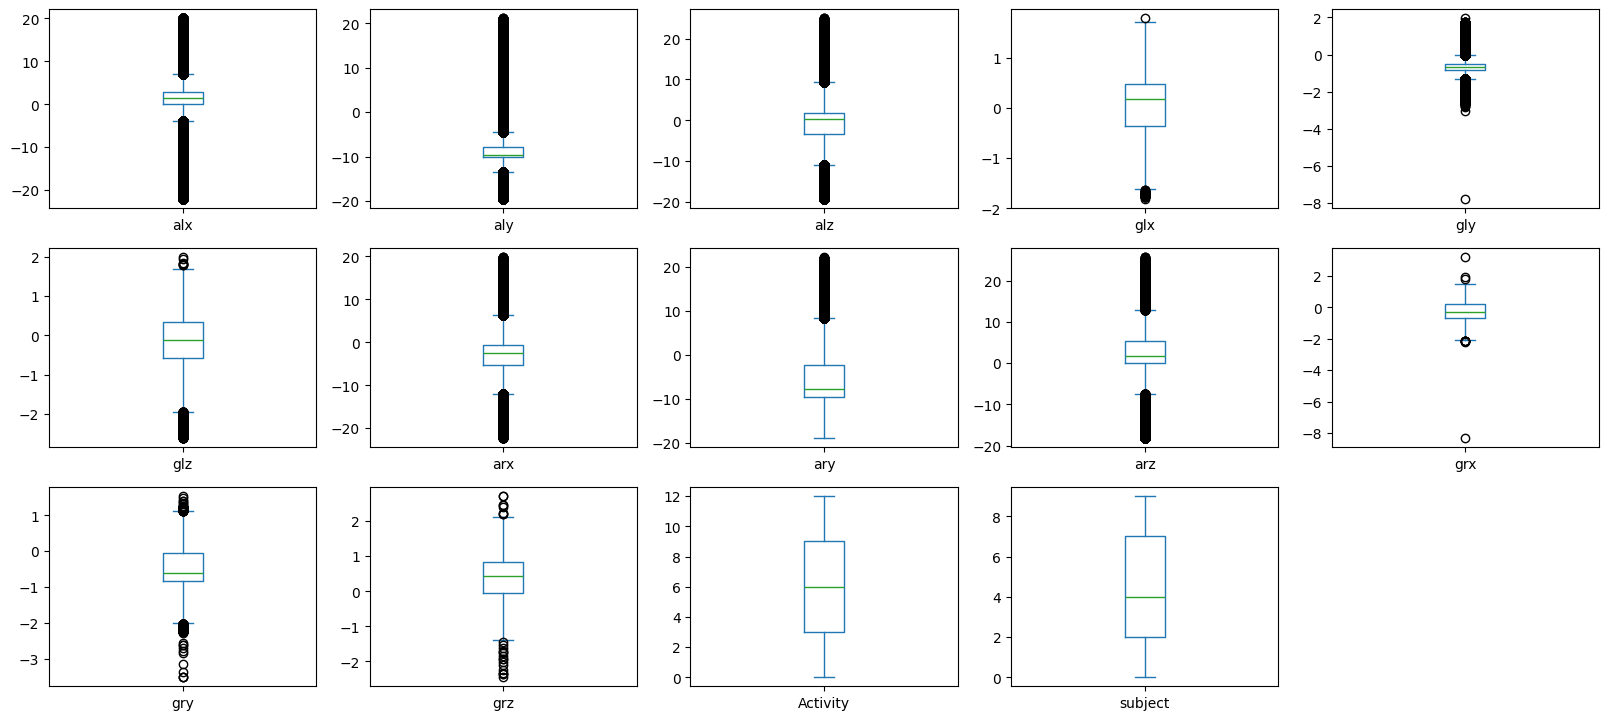

In [23]:
df.plot(kind='box', subplots=True, layout=(5,5), figsize=(20,15))
plt.show()

In [24]:
X = df.drop(["Activity", "subject"], axis=1).values
y = df['Activity'].values

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

In [26]:
ro_scaler = RobustScaler().fit(X_train)
X_train_scaled = ro_scaler.transform(X_train)
X_test_scaled = ro_scaler.transform(X_test)

In [27]:
#Building Model
def resultsSummarizer(y_true, y_pred, cm_en = True):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = sensitivity = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    if cm_en:
        plt.figure(figsize=(15,15))

        sns.heatmap(cm, annot = True, cmap = "Blues",xticklabels=activity_label.values(),yticklabels=activity_label.values())

        plt.title('Confusion Matrix')
        plt.show()

    print(f'Accuracy Score: ' + '{:.4%}'.format(acc))
    print(f'Precision Score: ' + '{:.4%}'.format(prec))
    print(f'Recall Score: ' + '{:.4%}'.format(rec))
    print(f'F1 Score: ' + '{:.4%}'.format(f1))

In [28]:
### 1. Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr=LogisticRegression()
lr.fit(X_train, y_train)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [29]:
lr.score(X_train, y_train)

0.5510515108073877

In [30]:
lr.score(X_test, y_test)

0.5498178477854675

In [31]:
lr2 = LogisticRegression(max_iter=1000)
lr2.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [32]:
lr2.score(X_train_scaled, y_train)

0.5553104427340673

In [33]:
lr2.score(X_test_scaled, y_test)

0.5545256213530413

In [34]:
y_pred_lr=lr2.predict(X_test_scaled)

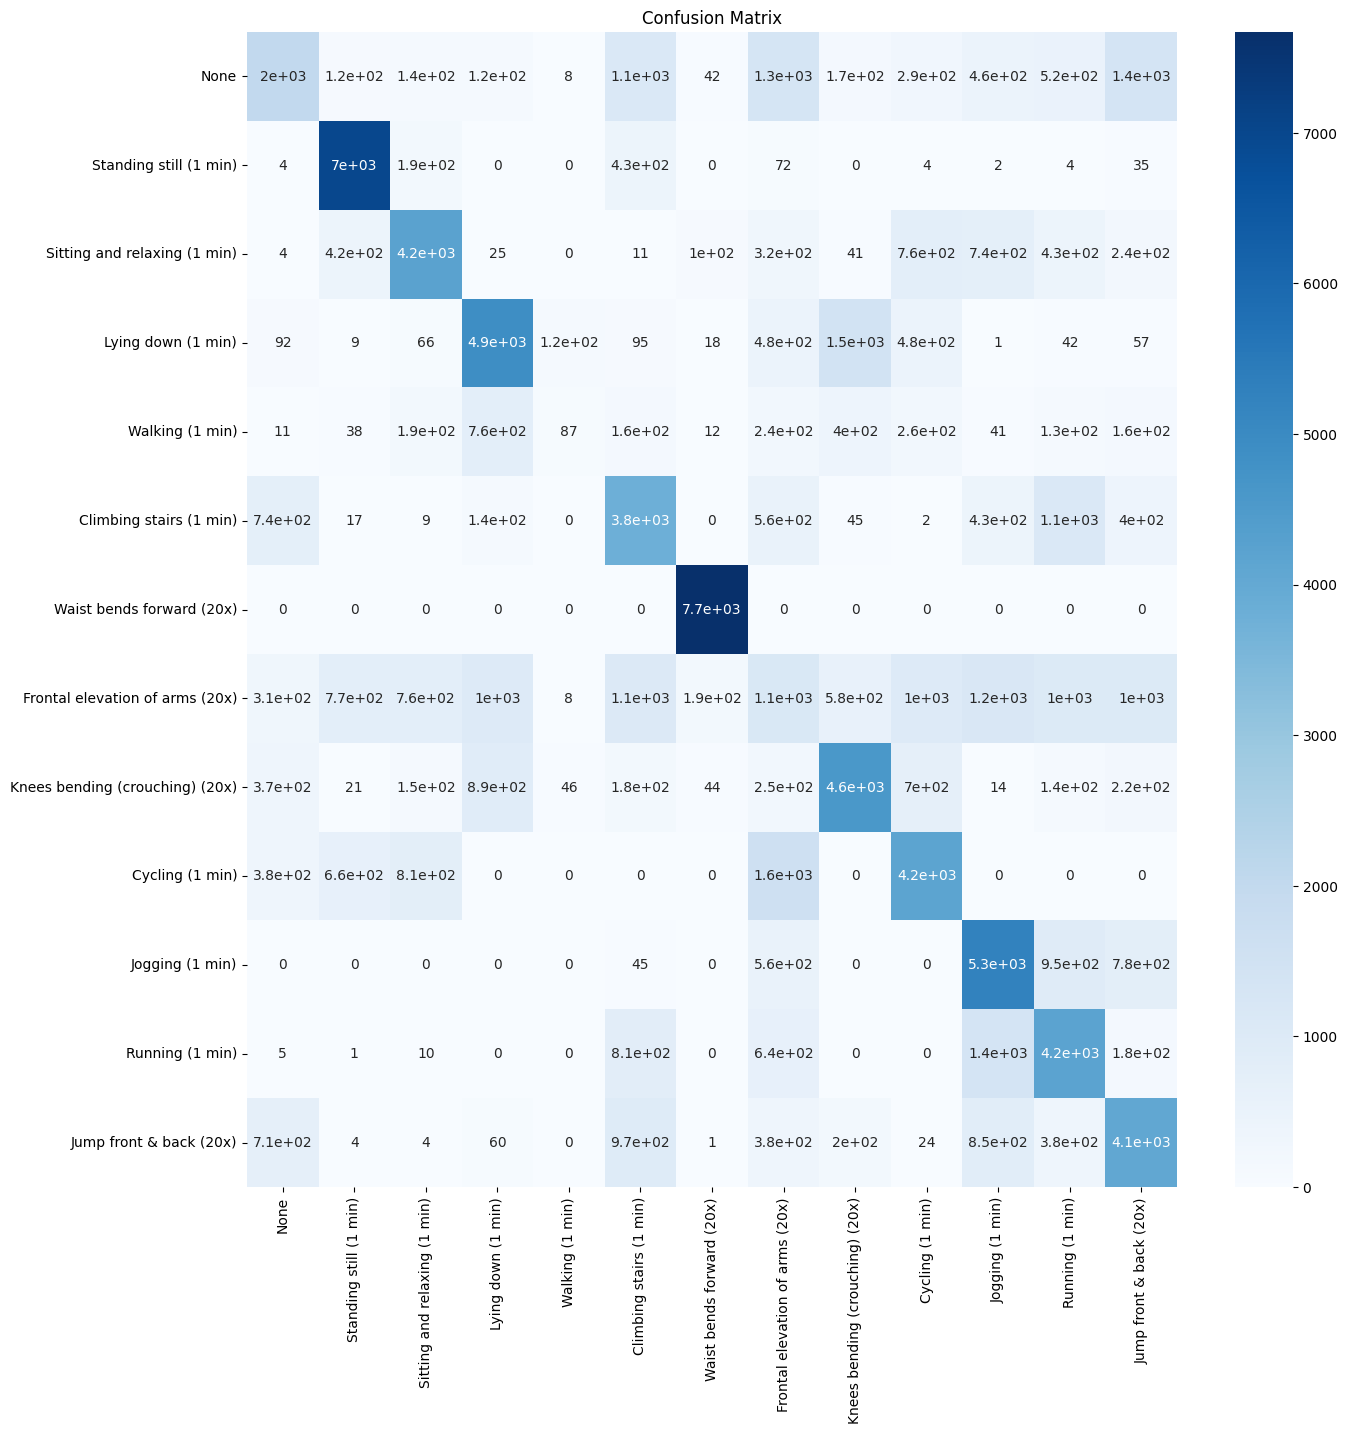

Accuracy Score: 55.4526%
Precision Score: 53.3564%
Recall Score: 53.8200%
F1 Score: 52.2722%


In [35]:
resultsSummarizer(y_test,y_pred_lr)

In [36]:
### 2. KNN
knn1 = KNeighborsClassifier(n_neighbors=5)
knn1.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [37]:
y_pred_knn=knn1.predict(X_test)

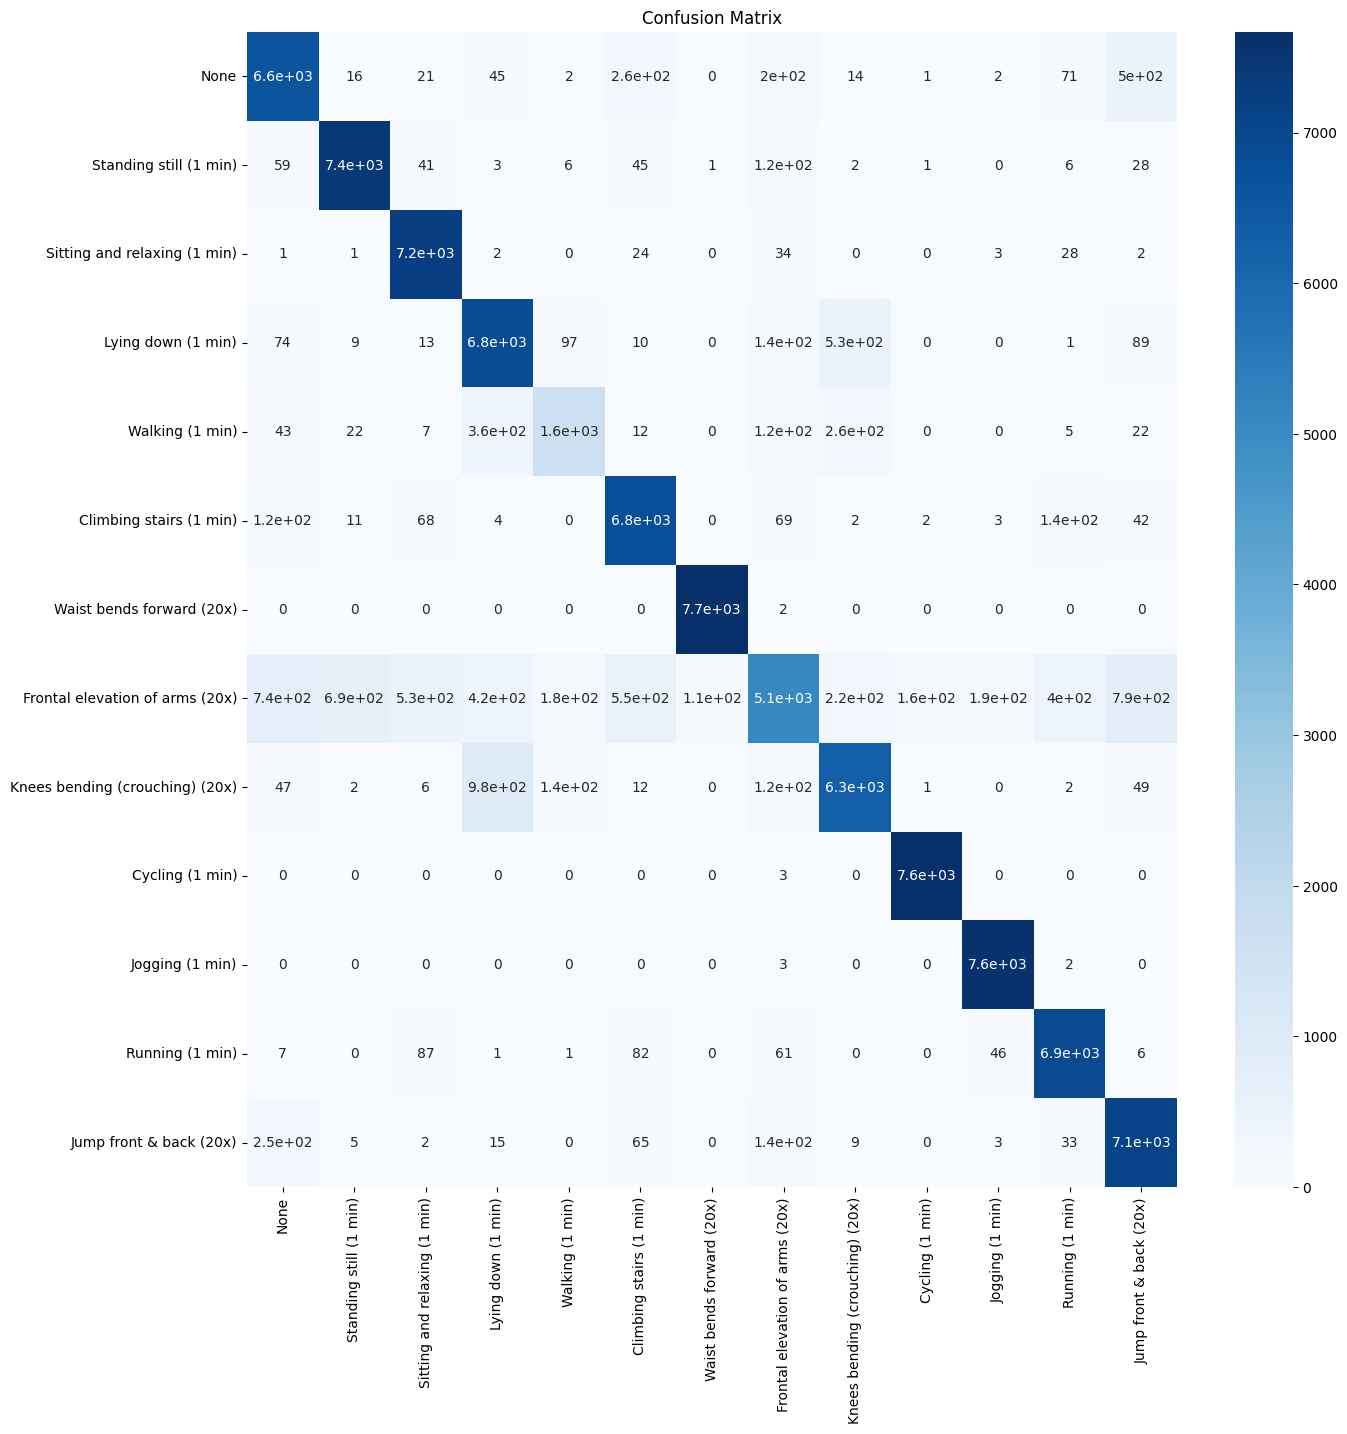

Accuracy Score: 88.5364%
Precision Score: 88.0595%
Recall Score: 88.3681%
F1 Score: 87.7663%


In [38]:
resultsSummarizer(y_test,y_pred_knn)

In [39]:
knn2 = KNeighborsClassifier(n_neighbors=5)
knn2.fit(X_train_scaled, y_train)
y_pred_knn2 = knn2.predict(X_test_scaled)

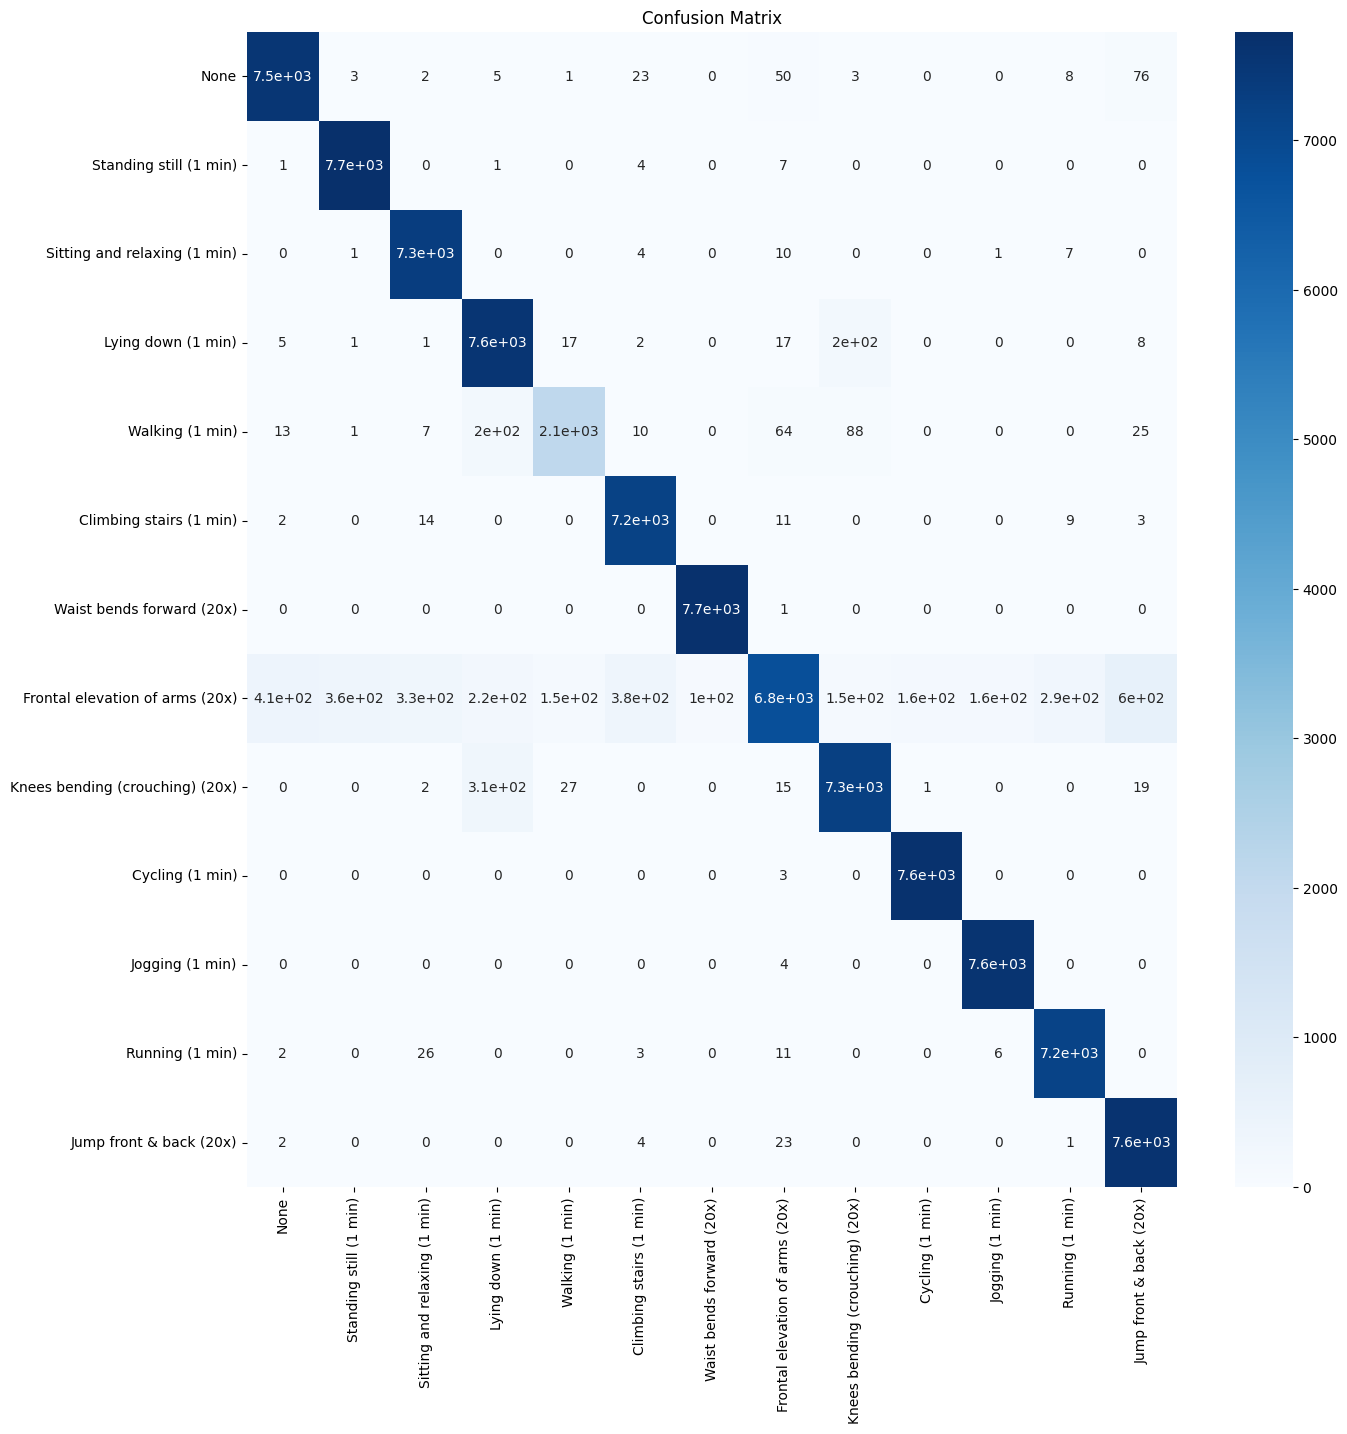

Accuracy Score: 95.1356%
Precision Score: 94.9974%
Recall Score: 95.2629%
F1 Score: 94.8707%


In [40]:
resultsSummarizer(y_test, y_pred_knn2)

In [42]:
for n in range(1,11):
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)
    print(f"\n=====No of Neighbors: {n}============\n")
    resultsSummarizer(y_test, y_pred, cm_en=False)


=====No of Neighbors: 1============

Accuracy Score: 95.3914%
Precision Score: 95.2283%
Recall Score: 95.4984%
F1 Score: 95.2915%

=====No of Neighbors: 2============

Accuracy Score: 94.8789%
Precision Score: 94.6781%
Recall Score: 95.0944%
F1 Score: 94.7500%

=====No of Neighbors: 3============

Accuracy Score: 95.4425%
Precision Score: 95.3062%
Recall Score: 95.5450%
F1 Score: 95.2090%

=====No of Neighbors: 4============

Accuracy Score: 95.1816%
Precision Score: 95.0336%
Recall Score: 95.3161%
F1 Score: 94.9261%

=====No of Neighbors: 5============

Accuracy Score: 95.1356%
Precision Score: 94.9974%
Recall Score: 95.2629%
F1 Score: 94.8707%

=====No of Neighbors: 6============

Accuracy Score: 94.9363%
Precision Score: 94.8305%
Recall Score: 95.0564%
F1 Score: 94.6515%

=====No of Neighbors: 7============

Accuracy Score: 94.8329%
Precision Score: 94.7509%
Recall Score: 94.9398%
F1 Score: 94.5381%

=====No of Neighbors: 8============

Accuracy Score: 94.6722%
Precision Score: 94.

In [45]:
dt=DecisionTreeClassifier(max_mdepth=14)
dt.fit(X_train,y_train)
y_pred_dt=dt.predict(X_train)
resultsSummarizer(y_test, y_pred_dt)

TypeError: DecisionTreeClassifier.__init__() got an unexpected keyword argument 'max_mdepth'. Did you mean 'max_depth'?